In [1]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Create a project folder in Drive if it doesn't exist
SAVE_PATH = '/content/drive/MyDrive/StablePFN_Project/'
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)
    print(f"Created directory: {SAVE_PATH}")
else:
    print(f"Files will be saved to: {SAVE_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files will be saved to: /content/drive/MyDrive/StablePFN_Project/


Rerunning the preprocessing cell now that `SAVE_PATH` is defined.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os

# Load CSV
df = pd.read_csv('Students-Social-Media-Addiction-1.csv')
print(f"Loaded: {df.shape}")

#   Step 1: Separate X and y
y = df['Addicted_Score'].copy()
X = df.drop(columns=['Addicted_Score', 'Student_ID'])

#   Step 2: Split train/val/test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

#   Step 3: Binary encode
X_train['Gender'] = (X_train['Gender'] == 'Male').astype(int)
X_val['Gender'] = (X_val['Gender'] == 'Male').astype(int)
X_test['Gender'] = (X_test['Gender'] == 'Male').astype(int)

X_train['Affects_Academic_Performance'] = (X_train['Affects_Academic_Performance'] == 'Yes').astype(int)
X_val['Affects_Academic_Performance'] = (X_val['Affects_Academic_Performance'] == 'Yes').astype(int)
X_test['Affects_Academic_Performance'] = (X_test['Affects_Academic_Performance'] == 'Yes').astype(int)

#   Step 4: Ordinal encode
academic_mapping = {'High School': 0, 'Undergraduate': 1, 'Graduate': 2}
X_train['Academic_Level'] = X_train['Academic_Level'].map(academic_mapping)
X_val['Academic_Level'] = X_val['Academic_Level'].map(academic_mapping)
X_test['Academic_Level'] = X_test['Academic_Level'].map(academic_mapping)

relationship_mapping = {'Single': 0, 'In Relationship': 1, 'Complicated': 2}
X_train['Relationship_Status'] = X_train['Relationship_Status'].map(relationship_mapping)
X_val['Relationship_Status'] = X_val['Relationship_Status'].map(relationship_mapping)
X_test['Relationship_Status'] = X_test['Relationship_Status'].map(relationship_mapping)

#   Step 5: Target encode Country (train-only statistics, no leakage)
X_train_temp = X_train.copy()
X_train_temp['target'] = y_train.values
country_target_means = X_train_temp.groupby('Country')['target'].mean()

X_train['Country'] = X_train['Country'].map(country_target_means)
X_val['Country'] = X_val['Country'].map(country_target_means)
X_test['Country'] = X_test['Country'].map(country_target_means)

global_mean = y_train.mean()
X_train['Country'] = X_train['Country'].fillna(global_mean)
X_val['Country'] = X_val['Country'].fillna(global_mean)
X_test['Country'] = X_test['Country'].fillna(global_mean)

#   Step 6: One-hot encode Platform
train_platform_dummies = pd.get_dummies(X_train['Most_Used_Platform'], prefix='Platform')
val_platform_dummies = pd.get_dummies(X_val['Most_Used_Platform'], prefix='Platform')
test_platform_dummies = pd.get_dummies(X_test['Most_Used_Platform'], prefix='Platform')

all_platform_cols = sorted(train_platform_dummies.columns.tolist())

for col in all_platform_cols:
    if col not in val_platform_dummies.columns:
        val_platform_dummies[col] = 0
    if col not in test_platform_dummies.columns:
        test_platform_dummies[col] = 0

val_platform_dummies = val_platform_dummies[all_platform_cols]
test_platform_dummies = test_platform_dummies[all_platform_cols]

X_train = X_train.drop(columns=['Most_Used_Platform'])
X_val = X_val.drop(columns=['Most_Used_Platform'])
X_test = X_test.drop(columns=['Most_Used_Platform'])

X_train = pd.concat([X_train, train_platform_dummies], axis=1)
X_val = pd.concat([X_val, val_platform_dummies], axis=1)
X_test = pd.concat([X_test, test_platform_dummies], axis=1)

#   Step 8: Convert to numpy
X_train_array = X_train.values.astype(np.float32)
X_val_array = X_val.values.astype(np.float32)
X_test_array = X_test.values.astype(np.float32)

y_train_array = y_train.values.astype(np.float32)
y_val_array = y_val.values.astype(np.float32)
y_test_array = y_test.values.astype(np.float32)

feature_names = X_train.columns.tolist()

print(f"\nPreprocessing complete!")
print(f"X_train: {X_train_array.shape}")
print(f"Features: {len(feature_names)}")
print(f"Addicted_Score range: {y.min()} - {y.max()}")

#   Step 9: Save (both locally for this session AND to Drive so it survives a restart)
np.savez('/content/sma10_processed.npz',
         X_train=X_train_array, X_val=X_val_array, X_test=X_test_array,
         y_train=y_train_array, y_val=y_val_array, y_test=y_test_array,
         feature_names=np.array(feature_names))

# Assuming SAVE_PATH is defined in a previous cell (uEXfBV4-Q6Y8)
np.savez(os.path.join(SAVE_PATH, 'sma10_processed.npz'),
         X_train=X_train_array, X_val=X_val_array, X_test=X_test_array,
         y_train=y_train_array, y_val=y_val_array, y_test=y_test_array,
         feature_names=np.array(feature_names))

print(f"✓ Saved to /content/sma10_processed.npz and {SAVE_PATH}sma10_processed.npz")

Loaded: (705, 13)
Train: 493, Val: 71, Test: 141

Preprocessing complete!
X_train: (493, 22)
Features: 22
Addicted_Score range: 2 - 9
✓ Saved to /content/sma10_processed.npz and /content/drive/MyDrive/StablePFN_Project/sma10_processed.npz


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os

# Load CSV
df = pd.read_csv('Students-Social-Media-Addiction-1.csv')
print(f"Loaded: {df.shape}")

#   Step 1: Separate X and y
y = df['Addicted_Score'].copy()
X = df.drop(columns=['Addicted_Score', 'Student_ID'])

#   Step 2: Split train/val/test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

#   Step 3: Binary encode
X_train['Gender'] = (X_train['Gender'] == 'Male').astype(int)
X_val['Gender'] = (X_val['Gender'] == 'Male').astype(int)
X_test['Gender'] = (X_test['Gender'] == 'Male').astype(int)

X_train['Affects_Academic_Performance'] = (X_train['Affects_Academic_Performance'] == 'Yes').astype(int)
X_val['Affects_Academic_Performance'] = (X_val['Affects_Academic_Performance'] == 'Yes').astype(int)
X_test['Affects_Academic_Performance'] = (X_test['Affects_Academic_Performance'] == 'Yes').astype(int)

#   Step 4: Ordinal encode
academic_mapping = {'High School': 0, 'Undergraduate': 1, 'Graduate': 2}
X_train['Academic_Level'] = X_train['Academic_Level'].map(academic_mapping)
X_val['Academic_Level'] = X_val['Academic_Level'].map(academic_mapping)
X_test['Academic_Level'] = X_test['Academic_Level'].map(academic_mapping)

relationship_mapping = {'Single': 0, 'In Relationship': 1, 'Complicated': 2}
X_train['Relationship_Status'] = X_train['Relationship_Status'].map(relationship_mapping)
X_val['Relationship_Status'] = X_val['Relationship_Status'].map(relationship_mapping)
X_test['Relationship_Status'] = X_test['Relationship_Status'].map(relationship_mapping)

#   Step 5: Target encode Country (train-only statistics, no leakage)
X_train_temp = X_train.copy()
X_train_temp['target'] = y_train.values
country_target_means = X_train_temp.groupby('Country')['target'].mean()

X_train['Country'] = X_train['Country'].map(country_target_means)
X_val['Country'] = X_val['Country'].map(country_target_means)
X_test['Country'] = X_test['Country'].map(country_target_means)

global_mean = y_train.mean()
X_train['Country'] = X_train['Country'].fillna(global_mean)
X_val['Country'] = X_val['Country'].fillna(global_mean)
X_test['Country'] = X_test['Country'].fillna(global_mean)

#   Step 6: One-hot encode Platform
train_platform_dummies = pd.get_dummies(X_train['Most_Used_Platform'], prefix='Platform')
val_platform_dummies = pd.get_dummies(X_val['Most_Used_Platform'], prefix='Platform')
test_platform_dummies = pd.get_dummies(X_test['Most_Used_Platform'], prefix='Platform')

all_platform_cols = sorted(train_platform_dummies.columns.tolist())

for col in all_platform_cols:
    if col not in val_platform_dummies.columns:
        val_platform_dummies[col] = 0
    if col not in test_platform_dummies.columns:
        test_platform_dummies[col] = 0

val_platform_dummies = val_platform_dummies[all_platform_cols]
test_platform_dummies = test_platform_dummies[all_platform_cols]

X_train = X_train.drop(columns=['Most_Used_Platform'])
X_val = X_val.drop(columns=['Most_Used_Platform'])
X_test = X_test.drop(columns=['Most_Used_Platform'])

X_train = pd.concat([X_train, train_platform_dummies], axis=1)
X_val = pd.concat([X_val, val_platform_dummies], axis=1)
X_test = pd.concat([X_test, test_platform_dummies], axis=1)

#   Step 8: Convert to numpy
X_train_array = X_train.values.astype(np.float32)
X_val_array = X_val.values.astype(np.float32)
X_test_array = X_test.values.astype(np.float32)

y_train_array = y_train.values.astype(np.float32)
y_val_array = y_val.values.astype(np.float32)
y_test_array = y_test.values.astype(np.float32)

feature_names = X_train.columns.tolist()

print(f"\nPreprocessing complete!")
print(f"X_train: {X_train_array.shape}")
print(f"Features: {len(feature_names)}")
print(f"Addicted_Score range: {y.min()} - {y.max()}")

#   Step 9: Save (both locally for this session AND to Drive so it survives a restart)
np.savez('/content/sma10_processed.npz',
         X_train=X_train_array, X_val=X_val_array, X_test=X_test_array,
         y_train=y_train_array, y_val=y_val_array, y_test=y_test_array,
         feature_names=np.array(feature_names))

#   Step 9: Save locally
np.savez('/content/sma10_processed.npz',
         X_train=X_train_array, X_val=X_val_array, X_test=X_test_array,
         y_train=y_train_array, y_val=y_val_array, y_test=y_test_array,
         feature_names=np.array(feature_names))

print("✓ Saved to /content/sma10_processed.npz")

Loaded: (705, 13)
Train: 493, Val: 71, Test: 141

Preprocessing complete!
X_train: (493, 22)
Features: 22
Addicted_Score range: 2 - 9
✓ Saved to /content/sma10_processed.npz


## 2. Torch setup

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [5]:
# Load the .npz file. Prefer the local copy (faster) but fall back to Drive
# so this cell still works after a runtime restart even if Cell 1 wasn't re-run.
local_path = '/content/sma10_processed.npz'
drive_path = os.path.join(SAVE_PATH, 'sma10_processed.npz')
npz_path = local_path if os.path.exists(local_path) else drive_path

data = np.load(npz_path)
print(f"Loaded processed data from: {npz_path}")

X_train = torch.tensor(data['X_train'], dtype=torch.float32)
X_val = torch.tensor(data['X_val'], dtype=torch.float32)
X_test = torch.tensor(data['X_test'], dtype=torch.float32)

y_train = torch.tensor(data['y_train'], dtype=torch.float32)
y_val = torch.tensor(data['y_val'], dtype=torch.float32)
y_test = torch.tensor(data['y_test'], dtype=torch.float32)

feature_names = data['feature_names']
feature_names_list = [str(f) for f in feature_names]

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

# Move to device
X_train, X_val, X_test = X_train.to(device), X_val.to(device), X_test.to(device)
y_train, y_val, y_test = y_train.to(device), y_val.to(device), y_test.to(device)


Loaded processed data from: /content/sma10_processed.npz
X_train: torch.Size([493, 22])
y_train: torch.Size([493])


In [6]:
# Batch size for training
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Train batches: 16
Val batches: 3
Test batches: 5


In [7]:
class StablePFN(nn.Module):

    def __init__(self,
                 n_features=22,
                 embedding_dim=128,
                 n_heads=4,
                 n_transformer_blocks=2,
                 ffn_hidden=256,
                 dropout=0.1,
                 device='cpu'):
        super().__init__()

        self.n_features = n_features
        self.embedding_dim = embedding_dim
        self.device = device

        #   COMPONENT 1: Input Embedding Layer
        self.input_embedding = nn.Linear(1, embedding_dim)

        #   COMPONENT 2: Feature ID Embeddings
        self.feature_id_embedding = nn.Embedding(n_features, embedding_dim)

        #   COMPONENT 3: Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=n_heads,
            dim_feedforward=ffn_hidden,
            dropout=dropout,
            batch_first=True,
            activation='relu'
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_transformer_blocks
        )

        self.discovery_projection = nn.Linear(embedding_dim, 1)

        # COMPONENT 5: Decoupling Branch
        self.decoupling_head = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim // 2),
            nn.ReLU(),
            nn.Linear(embedding_dim // 2, 1)
        )

        #   COMPONENT 6: Prediction Branch
        self.prediction_head = nn.Sequential(
            nn.Linear(embedding_dim, ffn_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_hidden, ffn_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_hidden // 2, 1)
        )

        self.layer_norm = nn.LayerNorm(embedding_dim)

    def forward(self, x):
        batch_size = x.shape[0]

        #   STEP 1 & 2: Embed input features + Feature IDs
        x_token_embeddings = []
        for i in range(self.n_features):
            feat_val = x[:, i].unsqueeze(-1)
            feat_embed = self.input_embedding(feat_val)
            x_token_embeddings.append(feat_embed)

        x_tokens = torch.stack(x_token_embeddings, dim=1)  # (batch_size, n_features, embedding_dim)

        feature_ids = torch.arange(self.n_features, device=self.device)
        feature_embeddings = self.feature_id_embedding(feature_ids)  # (n_features, embedding_dim)
        x_tokens = x_tokens + feature_embeddings.unsqueeze(0)

        x_tokens = self.layer_norm(x_tokens)

        #   STEP 3: Discovery Branch -- score each token BEFORE attention mixes them
        mb_scores_logits = self.discovery_projection(x_tokens)   # (batch_size, n_features, 1)
        mb_scores = torch.sigmoid(mb_scores_logits.squeeze(-1))  # (batch_size, n_features)
        mb_scores_global = mb_scores.mean(dim=0)                 # (n_features,)
        mb_logits_global = mb_scores_logits.squeeze(-1).mean(dim=0)  # (n_features,) -- for L_logit_l2

        # ---- FIX: gate the RAW tokens before self-attention. A feature whose
        # gate is ~0 is genuinely excluded -- its info can no longer leak into
        # other tokens' representations, unlike gating transformer_out. ----
        gated_tokens = x_tokens * mb_scores.unsqueeze(-1)  # (batch_size, n_features, embedding_dim)

        #   STEP 4: Transformer (now operates on the already-gated tokens)
        transformer_out = self.transformer_encoder(gated_tokens)  # (batch_size, n_features, embedding_dim)
        pooled = transformer_out.mean(dim=1)                      # (batch_size, embedding_dim)

        #   STEP 5: Decoupling Branch
        sample_weights_logits = self.decoupling_head(pooled)  # (batch_size, 1)
        sample_weights = torch.softmax(sample_weights_logits.squeeze(-1), dim=-1)  # (batch_size,)

        #   STEP 6: Prediction Branch
        y_pred = self.prediction_head(pooled).squeeze(-1)  # (batch_size,)
        # NOTE: no clamp here -- clamp only at inference time if you need it,
        # e.g. y_pred_reported = torch.clamp(y_pred, min=2.0, max=9.0) AFTER model.eval()/no_grad().

        return y_pred, mb_scores_global, sample_weights, mb_logits_global

    def predict_with_masking(self, x, threshold=0.5):
        """Hard-mask the raw input features whose global MB score is below threshold, then re-predict."""
        with torch.no_grad():
            _, mb_scores, _, _ = self.forward(x)
        mb_mask = (mb_scores >= threshold).float()
        x_masked = x * mb_mask.unsqueeze(0)
        y_masked, _, _, _ = self.forward(x_masked)
        return y_masked, mb_scores, mb_mask


# Initialize model
model = StablePFN(
    n_features=len(feature_names_list),
    embedding_dim=128,
    n_heads=4,
    n_transformer_blocks=2,
    ffn_hidden=256,
    dropout=0.1,
    device=device
).to(device)

print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")


Model created with 342787 parameters


## 4. Optimizer & scheduler

In [8]:
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)


In [9]:
class StablePFNLoss(nn.Module):
    def __init__(self, lambda1=0.1, lambda2=2.0, lambda3=1.0, lambda4=0.5, lambda5=0.01):
        super().__init__()
        self.lambda1 = lambda1
        self.lambda2 = lambda2   # weight on L_mb -- set per-epoch by the annealing schedule in train_model
        self.lambda3 = lambda3
        self.lambda4 = lambda4   # sparsity pressure (raised from 0.1 -> 0.5, see markdown above)
        self.lambda5 = lambda5   # NEW: logit-L2, keeps gates from saturating out of reach of lambda4

    def forward(self, y_pred, y_true, mb_scores, sample_weights, mb_scores_logits):
        # L_pred: sample-weighted regression loss
        per_sample_se = (y_pred - y_true) ** 2
        L_pred = (sample_weights * per_sample_se).sum()

        # L_w: entropy regularization on the sample weights
        eps = 1e-8
        L_w = -(sample_weights * torch.log(sample_weights + eps)).sum()

        # L_mb: MB discovery regularization (push scores away from 0.5, towards a decision)
        L_mb = torch.mean(4 * mb_scores * (1 - mb_scores))

        # L_sparsity: penalizes keeping many features "on", forcing real trade-offs
        L_sparsity = mb_scores.mean()

        # L_logit_l2 (NEW): direct penalty on the pre-sigmoid logits so the gradient
        # never fully vanishes even once a gate has saturated near 0 or 1.
        L_logit_l2 = torch.mean(mb_scores_logits ** 2)

        total_loss = (self.lambda1 * L_w + self.lambda2 * L_mb
                      + self.lambda3 * L_pred + self.lambda4 * L_sparsity
                      + self.lambda5 * L_logit_l2)

        return total_loss, L_pred, L_w, L_mb, L_sparsity, L_logit_l2


loss_fn = StablePFNLoss(lambda1=0.1, lambda2=2.0, lambda3=1.0, lambda4=0.5, lambda5=0.01)


In [10]:
def train_epoch(model, train_loader, optimizer, loss_fn, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    total_pred_loss = 0
    total_w_loss = 0
    total_mb_loss = 0
    total_sparsity_loss = 0
    total_logitl2_loss = 0

    for X_batch, y_batch in tqdm(train_loader, desc="Training"):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred, mb_scores, sample_weights, mb_scores_logits = model(X_batch)
        total, L_pred, L_w, L_mb, L_sparsity, L_logit_l2 = loss_fn(
            y_pred, y_batch, mb_scores, sample_weights, mb_scores_logits
        )

        optimizer.zero_grad()
        total.backward()
        optimizer.step()

        total_loss += total.item()
        total_pred_loss += L_pred.item()
        total_w_loss += L_w.item()
        total_mb_loss += L_mb.item()
        total_sparsity_loss += L_sparsity.item()
        total_logitl2_loss += L_logit_l2.item()

    n_batches = len(train_loader)
    return {
        'total': total_loss / n_batches,
        'pred': total_pred_loss / n_batches,
        'w': total_w_loss / n_batches,
        'mb': total_mb_loss / n_batches,
        'sparsity': total_sparsity_loss / n_batches,
        'logit_l2': total_logitl2_loss / n_batches
    }


def validate(model, val_loader, loss_fn, device):
    """Validate model"""
    model.eval()
    total_loss = 0
    y_preds = []
    y_trues = []

    with torch.no_grad():
        for X_batch, y_batch in tqdm(val_loader, desc="Validating"):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred, mb_scores, sample_weights, mb_scores_logits = model(X_batch)
            total, _, _, _, _, _ = loss_fn(y_pred, y_batch, mb_scores, sample_weights, mb_scores_logits)
            total_loss += total.item()

            y_preds.append(y_pred.cpu().numpy())
            y_trues.append(y_batch.cpu().numpy())

    y_preds = np.concatenate(y_preds)
    y_trues = np.concatenate(y_trues)

    mse = np.mean((y_preds - y_trues) ** 2)
    mae = np.mean(np.abs(y_preds - y_trues))

    return {
        'loss': total_loss / len(val_loader),
        'mse': mse,
        'mae': mae
    }, y_preds, y_trues


def train_model(model, train_loader, val_loader, optimizer, scheduler, loss_fn,
                device, n_epochs=100, patience=15, checkpoint_path='best_stablepfn.pt',
                lambda2_target=2.0, warmup_epochs=5, anneal_epochs=15):
    """Full training loop with early stopping and lambda2 (MB-extremeness) annealing.

    For the first `warmup_epochs`, loss_fn.lambda2 is held at 0. It then ramps
    linearly up to `lambda2_target` over the next `anneal_epochs`, and stays
    there. This is what stops every MB gate from being pushed to an extreme
    (all saturating at ~1.0) before the model has learned which features
    actually matter -- see the markdown notes above for the full diagnosis.
    """

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(n_epochs):
        if epoch < warmup_epochs:
            loss_fn.lambda2 = 0.0
        else:
            frac = min(1.0, (epoch - warmup_epochs) / max(1, anneal_epochs))
            loss_fn.lambda2 = lambda2_target * frac

        train_metrics = train_epoch(model, train_loader, optimizer, loss_fn, device)
        train_losses.append(train_metrics['total'])

        val_metrics, _, _ = validate(model, val_loader, loss_fn, device)
        val_losses.append(val_metrics['loss'])

        scheduler.step()

        print(f"\nEpoch {epoch+1}/{n_epochs}  (lambda2={loss_fn.lambda2:.3f})")
        print(f"  Train Loss: {train_metrics['total']:.4f} "
              f"(Pred: {train_metrics['pred']:.4f}, W: {train_metrics['w']:.4f}, "
              f"MB: {train_metrics['mb']:.4f}, Sparsity: {train_metrics['sparsity']:.4f}, "
              f"LogitL2: {train_metrics['logit_l2']:.4f})")
        print(f"  Val Loss: {val_metrics['loss']:.4f}, MSE: {val_metrics['mse']:.4f}, MAE: {val_metrics['mae']:.4f}")

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    return train_losses, val_losses


## 7. Train

Validating: 100%|██████████| 3/3 [00:00<00:00, 59.35it/s]



Epoch 1/100  (lambda2=0.000)
  Train Loss: 39.3511 (Pred: 38.7576, W: 3.4094, MB: 0.9369, Sparsity: 0.4996, LogitL2: 0.2823)
  Val Loss: 34.3165, MSE: 33.8944, MAE: 5.6047


Validating: 100%|██████████| 3/3 [00:00<00:00, 131.51it/s]



Epoch 2/100  (lambda2=0.000)
  Train Loss: 29.9464 (Pred: 29.3605, W: 3.4094, MB: 0.9325, Sparsity: 0.4837, LogitL2: 0.3072)
  Val Loss: 23.7499, MSE: 23.4314, MAE: 4.5772


Validating: 100%|██████████| 3/3 [00:00<00:00, 70.74it/s]


...


Epoch 98/100  (lambda2=2.000)
  Train Loss: 0.9629 (Pred: 0.3946, W: 2.3576, MB: 0.0822, Sparsity: 0.0211, LogitL2: 15.7713)
  Val Loss: 0.8419, MSE: 0.5497, MAE: 0.6370


Validating: 100%|██████████| 3/3 [00:00<00:00, 199.64it/s]



Epoch 99/100  (lambda2=2.000)
  Train Loss: 0.9173 (Pred: 0.3501, W: 2.3463, MB: 0.0822, Sparsity: 0.0211, LogitL2: 15.7713)
  Val Loss: 0.8431, MSE: 0.5499, MAE: 0.6372


Validating: 100%|██████████| 3/3 [00:00<00:00, 182.13it/s]



Epoch 100/100  (lambda2=2.000)
  Train Loss: 0.9155 (Pred: 0.3509, W: 2.3212, MB: 0.0821, Sparsity: 0.0210, LogitL2: 15.7735)
  Val Loss: 0.8448, MSE: 0.5501, MAE: 0.6375


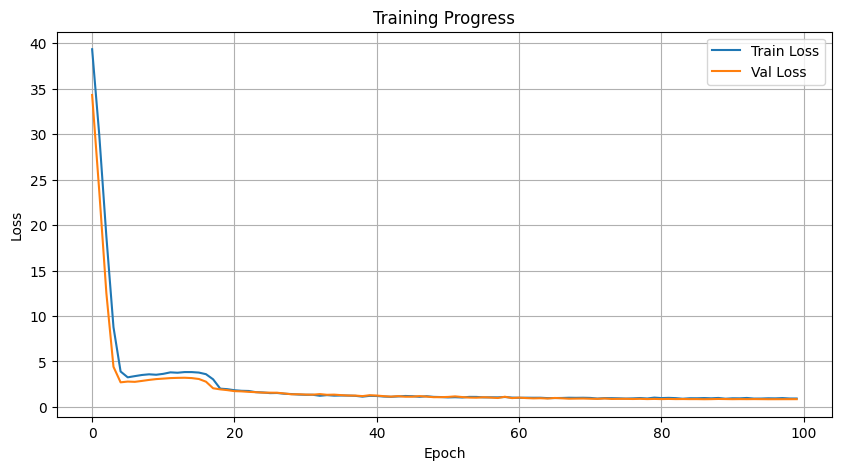

In [11]:
train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_fn=loss_fn,
    device=device,
    n_epochs=100,
    patience=15,
    checkpoint_path='best_stablepfn.pt',
    lambda2_target=2.0,   # final MB-extremeness weight once annealing completes
    warmup_epochs=5,      # no MB/sparsity pressure at all for the first 5 epochs
    anneal_epochs=15      # then ramp lambda2 up to its target over 15 epochs
)

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Progress')
plt.grid()
plt.show()


## 8. Evaluate on test set

In [12]:
# Load best model
model.load_state_dict(torch.load('best_stablepfn.pt'))
model.eval()

y_test_preds = []
y_test_trues = []
mb_scores_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred, mb_scores, _, _ = model(X_batch)

        y_test_preds.append(y_pred.cpu().numpy())
        y_test_trues.append(y_batch.cpu().numpy())
        mb_scores_list.append(mb_scores.cpu().numpy())

y_test_preds = np.concatenate(y_test_preds)
y_test_trues = np.concatenate(y_test_trues)
mb_scores_global = np.stack(mb_scores_list, axis=0).mean(axis=0)

test_mse = np.mean((y_test_preds - y_test_trues) ** 2)
test_mae = np.mean(np.abs(y_test_preds - y_test_trues))
test_r2 = 1 - (np.sum((y_test_preds - y_test_trues) ** 2) / np.sum((y_test_trues - y_test_trues.mean()) ** 2))

print("\n" + "=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"MSE: {test_mse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"R² Score: {test_r2:.4f}")

print("\n" + "=" * 60)
print("MARKOV BOUNDARY (Causal Features)")
print("=" * 60)
mb_ranking = sorted(zip(feature_names_list, mb_scores_global), key=lambda x: x[1], reverse=True)
for feat, score in mb_ranking[:10]:
    print(f"{feat:35s}: {score:.4f}")



TEST SET RESULTS
MSE: 0.5080
MAE: 0.5909
R² Score: 0.7970

MARKOV BOUNDARY (Causal Features)
Platform_YouTube                   : 0.0408
Platform_Twitter                   : 0.0356
Platform_TikTok                    : 0.0333
Platform_Snapchat                  : 0.0320
Affects_Academic_Performance       : 0.0303
Age                                : 0.0300
Platform_KakaoTalk                 : 0.0236
Gender                             : 0.0216
Platform_WhatsApp                  : 0.0213
Platform_Instagram                 : 0.0209


CLASSIFICATION METRICS (threshold >= 6.0)
Accuracy:  0.9433
Precision: 0.9080
Recall:    1.0000
F1 Score:  0.9518

Confusion Matrix:
True Negatives:  54
False Positives: 8
False Negatives: 0
True Positives:  79


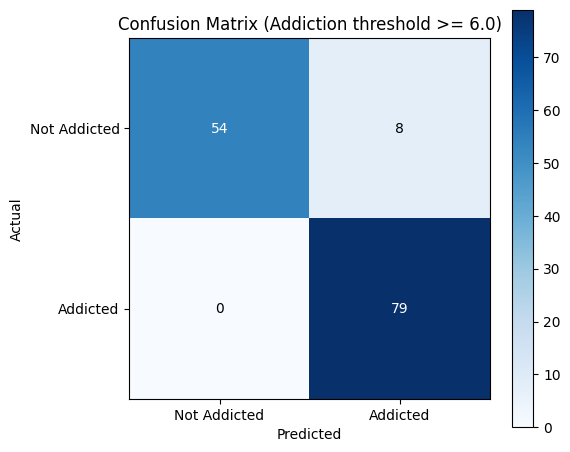

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# Define threshold: addiction score >= 7 is "Addicted"
threshold = 7.0
y_pred_binary = (y_test_preds >= threshold).astype(int)
y_true_binary = (y_test_trues >= threshold).astype(int)

accuracy = accuracy_score(y_true_binary, y_pred_binary)
precision = precision_score(y_true_binary, y_pred_binary)
recall = recall_score(y_true_binary, y_pred_binary)
f1 = f1_score(y_true_binary, y_pred_binary)

print("=" * 60)
print("CLASSIFICATION METRICS (threshold >= 6.0)")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true_binary, y_pred_binary)
print("\nConfusion Matrix:")
print(f"True Negatives:  {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives:  {cm[1,1]}")

# Visualize
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix (Addiction threshold >= 6.0)')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Not Addicted', 'Addicted'])
plt.yticks([0, 1], ['Not Addicted', 'Addicted'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()

## 9. Evaluate with hard MB masking

In [14]:
# Get MB scores and create mask
threshold = 0.5
mb_mask = (mb_scores_global >= threshold).astype(int)

print(f"\nCausal features (threshold={threshold}):")
causal_features = [f for f, m in zip(feature_names_list, mb_mask) if m == 1]
print(f"Count: {len(causal_features)}")
print(f"Features: {causal_features}")

y_test_preds_masked = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        mb_mask_tensor = torch.tensor(mb_mask, dtype=torch.float32, device=device)
        X_batch_masked = X_batch * mb_mask_tensor.unsqueeze(0)

        y_pred_masked, _, _, _ = model(X_batch_masked)
        y_test_preds_masked.append(y_pred_masked.cpu().numpy())

y_test_preds_masked = np.concatenate(y_test_preds_masked)

test_mse_masked = np.mean((y_test_preds_masked - y_test_trues) ** 2)
test_mae_masked = np.mean(np.abs(y_test_preds_masked - y_test_trues))

print("\n" + "=" * 60)
print("TEST SET RESULTS WITH HARD MB MASKING")
print("=" * 60)
print(f"MSE: {test_mse_masked:.4f} (vs {test_mse:.4f} without masking)")
print(f"MAE: {test_mae_masked:.4f} (vs {test_mae:.4f} without masking)")



Causal features (threshold=0.5):
Count: 0
Features: []

TEST SET RESULTS WITH HARD MB MASKING
MSE: 32.3024 (vs 0.5080 without masking)
MAE: 5.4589 (vs 0.5909 without masking)


In [15]:
# Delete old checkpoint file
if os.path.exists('best_stablepfn.pt'):
    os.remove('best_stablepfn.pt')

# ---- reinitialize the model, optimizer, scheduler, AND loss_fn (fresh lambda2 annealing) ----
model = StablePFN(
    n_features=len(feature_names_list),
    embedding_dim=128,
    n_heads=4,
    n_transformer_blocks=2,
    ffn_hidden=256,
    dropout=0.1,
    device=device
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)
loss_fn = StablePFNLoss(lambda1=0.1, lambda2=2.0, lambda3=1.0, lambda4=0.5, lambda5=0.01)

train_losses, val_losses = train_model(
    model, train_loader, val_loader,
    optimizer, scheduler, loss_fn,
    device=device,
    n_epochs=100,
    patience=15,
    checkpoint_path='best_stablepfn.pt',
    lambda2_target=2.0,
    warmup_epochs=5,
    anneal_epochs=15
)


Validating: 100%|██████████| 3/3 [00:00<00:00, 182.80it/s]



Epoch 1/100  (lambda2=0.000)
  Train Loss: 41.0623 (Pred: 40.4930, W: 3.4094, MB: 0.9462, Sparsity: 0.4519, LogitL2: 0.2410)
  Val Loss: 36.9758, MSE: 36.5639, MAE: 5.8370


Validating: 100%|██████████| 3/3 [00:00<00:00, 209.15it/s]



Epoch 2/100  (lambda2=0.000)
  Train Loss: 32.8791 (Pred: 32.3189, W: 3.4094, MB: 0.9380, Sparsity: 0.4328, LogitL2: 0.2799)
  Val Loss: 27.5149, MSE: 27.2251, MAE: 4.9737


Validating: 100%|██████████| 3/3 [00:00<00:00, 158.65it/s]


...


Epoch 98/100  (lambda2=2.000)
  Train Loss: 0.9361 (Pred: 0.3794, W: 2.2958, MB: 0.0702, Sparsity: 0.0180, LogitL2: 17.7677)
  Val Loss: 0.8464, MSE: 0.5625, MAE: 0.6053


Validating: 100%|██████████| 3/3 [00:00<00:00, 218.30it/s]



Epoch 99/100  (lambda2=2.000)
  Train Loss: 0.8991 (Pred: 0.3426, W: 2.2939, MB: 0.0702, Sparsity: 0.0180, LogitL2: 17.7659)
  Val Loss: 0.8439, MSE: 0.5616, MAE: 0.6047


Validating: 100%|██████████| 3/3 [00:00<00:00, 208.65it/s]


Epoch 100/100  (lambda2=2.000)
  Train Loss: 0.9315 (Pred: 0.3721, W: 2.3210, MB: 0.0703, Sparsity: 0.0180, LogitL2: 17.7630)
  Val Loss: 0.8474, MSE: 0.5631, MAE: 0.6058


## 11. Plots

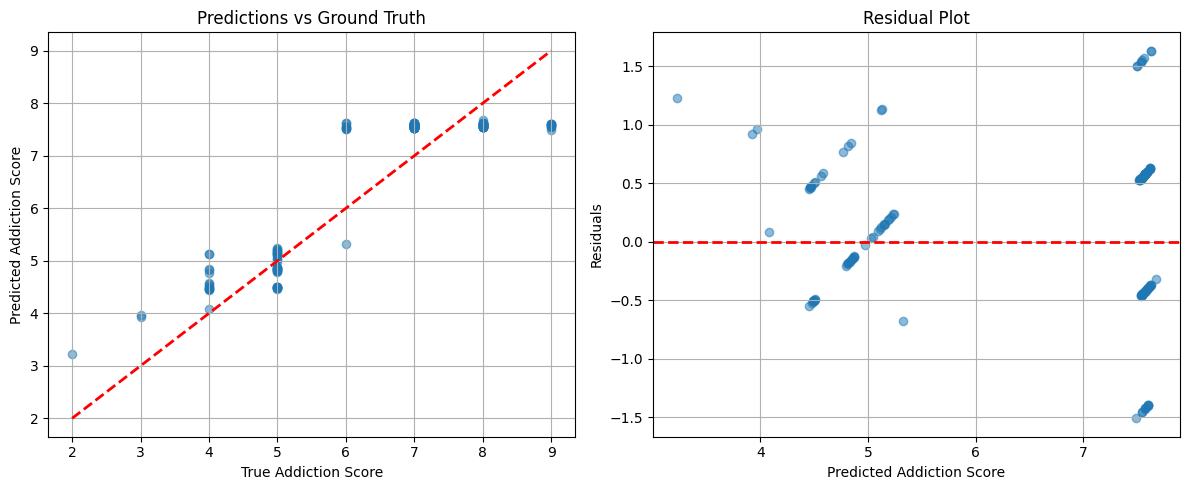

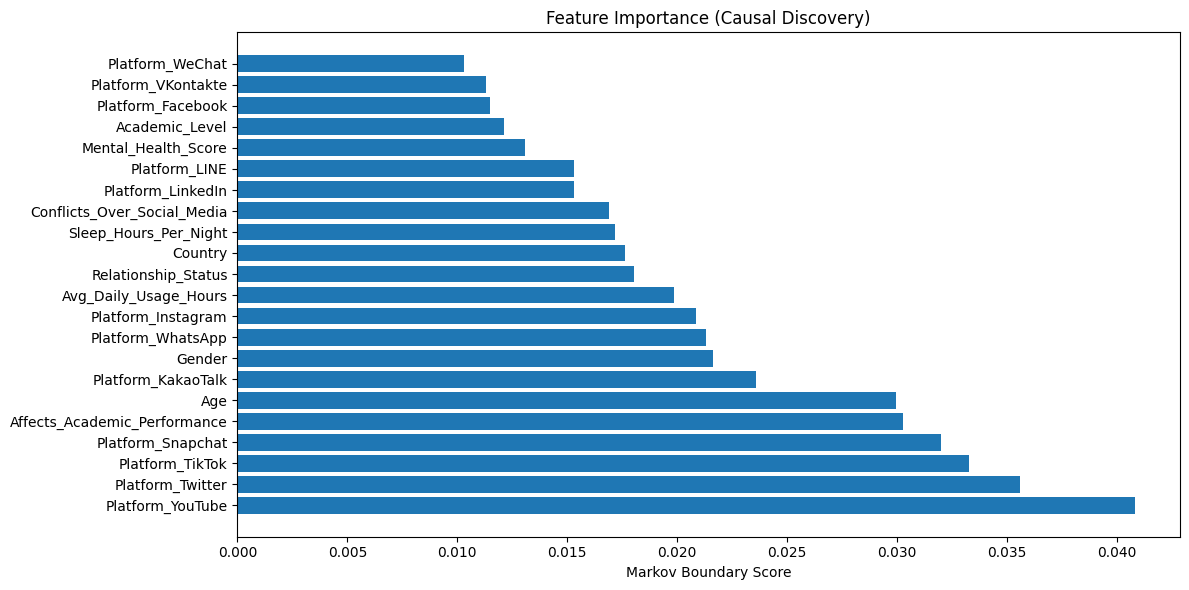

In [16]:
# Plot predictions vs ground truth
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_trues, y_test_preds, alpha=0.5)
plt.plot([y_test_trues.min(), y_test_trues.max()],
         [y_test_trues.min(), y_test_trues.max()], 'r--', lw=2)
plt.xlabel('True Addiction Score')
plt.ylabel('Predicted Addiction Score')
plt.title('Predictions vs Ground Truth')
plt.grid()

# Residuals plot
plt.subplot(1, 2, 2)
residuals = y_test_preds - y_test_trues
plt.scatter(y_test_preds, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Addiction Score')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid()
plt.tight_layout()
plt.show()

# MB scores visualization
plt.figure(figsize=(12, 6))
features_sorted = sorted(zip(feature_names_list, mb_scores_global),
                        key=lambda x: x[1], reverse=True)
feats, scores = zip(*features_sorted)
plt.barh(feats, scores)
plt.xlabel('Markov Boundary Score')
plt.title('Feature Importance (Causal Discovery)')
plt.tight_layout()
plt.show()


In [17]:
pip install iltm --break-system-packages

In [33]:
from iltm import iLTMRegressor
import time
import numpy as np # Added import for numpy

# Re-load the data from the .npz file
local_path = '/content/sma10_processed.npz'
data = np.load(local_path) # Added data loading

# Use the SAME numpy arrays / split that StablePFN was trained on (loaded back in Cell 5's
# `data` object as plain numpy, before they were converted to torch tensors) -- this is what
# keeps the comparison apples-to-apples.
X_train_np = data['X_train']
X_test_np = data['X_test']
y_train_np = data['y_train']
y_test_np = data['y_test']

print(f"Train shape: {X_train_np.shape}, Test shape: {X_test_np.shape}")

start = time.time()
iltm_reg = iLTMRegressor(
    checkpoint="xgbrconcat",   # pre-trained checkpoint, see markdown above
    device="cuda:0" if torch.cuda.is_available() else "cpu",
    clip_predictions=True,     # clamp predictions to the observed train-target range (2-9 here)
)
iltm_reg.fit(X_train_np, y_train_np)
fit_time = time.time() - start
print(f"iLTM fit (mostly just running our data through pre-trained weights) took {fit_time:.1f}s")

y_iltm_preds = iltm_reg.predict(X_test_np)

Train shape: (493, 22), Test shape: (141, 22)
iLTM fit (mostly just running our data through pre-trained weights) took 92.4s


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

iltm_mse = mean_squared_error(y_test_np, y_iltm_preds)
iltm_mae = mean_absolute_error(y_test_np, y_iltm_preds)
iltm_r2 = r2_score(y_test_np, y_iltm_preds)

print("=" * 60)
print("iLTM TEST SET RESULTS")
print("=" * 60)
print(f"MSE: {iltm_mse:.4f}")
print(f"MAE: {iltm_mae:.4f}")
print(f"R² Score: {iltm_r2:.4f}")

iLTM TEST SET RESULTS
MSE: 0.0675
MAE: 0.1796
R² Score: 0.9730


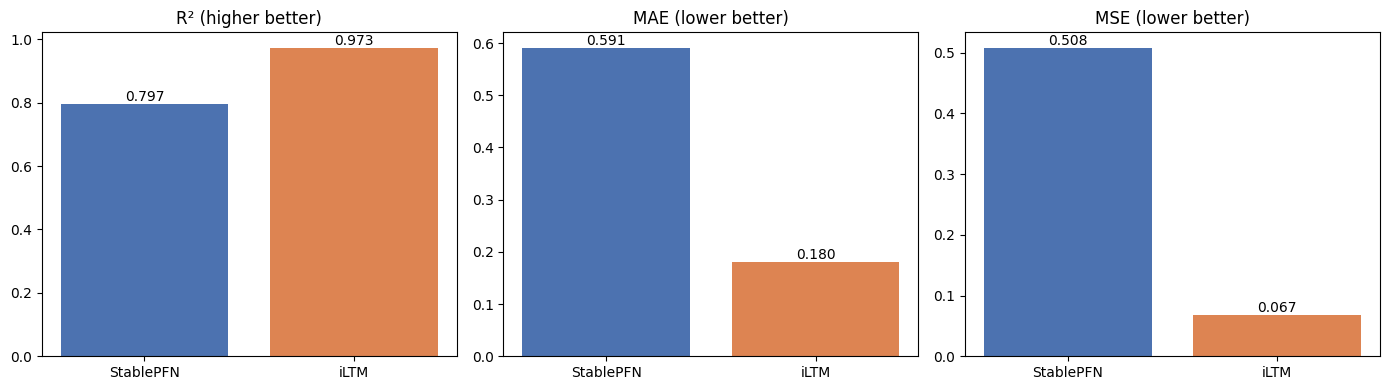

Metric        StablePFN         iLTM
R²               0.7970       0.9730
MAE              0.5909       0.1796
MSE              0.5080       0.0675


In [20]:
import matplotlib.pyplot as plt

metrics = ['R\u00b2 (higher better)', 'MAE (lower better)', 'MSE (lower better)']
stablepfn_vals = [test_r2, test_mae, test_mse]
iltm_vals = [iltm_r2, iltm_mae, iltm_mse]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, spfn_val, iltm_val in zip(axes, metrics, stablepfn_vals, iltm_vals):
    ax.bar(['StablePFN', 'iLTM'], [spfn_val, iltm_val], color=['#4C72B0', '#DD8452'])
    ax.set_title(metric)
    for i, v in enumerate([spfn_val, iltm_val]):
        ax.text(i, v, f"{v:.3f}", ha='center', va='bottom' if v >= 0 else 'top')
plt.tight_layout()
plt.show()

print(f"{'Metric':10s} {'StablePFN':>12s} {'iLTM':>12s}")
print(f"{'R²':10s} {test_r2:12.4f} {iltm_r2:12.4f}")
print(f"{'MAE':10s} {test_mae:12.4f} {iltm_mae:12.4f}")
print(f"{'MSE':10s} {test_mse:12.4f} {iltm_mse:12.4f}")

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

threshold = 6.0
y_iltm_pred_binary = (y_iltm_preds >= threshold).astype(int)
y_true_binary = (y_test_np >= threshold).astype(int)

iltm_accuracy = accuracy_score(y_true_binary, y_iltm_pred_binary)
iltm_precision = precision_score(y_true_binary, y_iltm_pred_binary)
iltm_recall = recall_score(y_true_binary, y_iltm_pred_binary)
iltm_f1 = f1_score(y_true_binary, y_iltm_pred_binary)

print("=" * 60)
print("iLTM CLASSIFICATION METRICS (threshold >= 6.0)")
print("=" * 60)
print(f"Accuracy:  {iltm_accuracy:.4f}")
print(f"Precision: {iltm_precision:.4f}")
print(f"Recall:    {iltm_recall:.4f}")
print(f"F1 Score:  {iltm_f1:.4f}")

cm = confusion_matrix(y_true_binary, y_iltm_pred_binary)
print("\nConfusion Matrix:")
print(f"True Negatives:  {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives:  {cm[1,1]}")

print("\n" + "=" * 60)
print("StablePFN vs iLTM -- Classification Comparison")
print("=" * 60)
print(f"{'Metric':10s} {'StablePFN':>12s} {'iLTM':>12s}")
print(f"{'Accuracy':10s} {accuracy:12.4f} {iltm_accuracy:12.4f}")
print(f"{'Precision':10s} {precision:12.4f} {iltm_precision:12.4f}")
print(f"{'Recall':10s} {recall:12.4f} {iltm_recall:12.4f}")
print(f"{'F1':10s} {f1:12.4f} {iltm_f1:12.4f}")

iLTM CLASSIFICATION METRICS (threshold >= 6.0)
Accuracy:  0.9716
Precision: 1.0000
Recall:    0.9545
F1 Score:  0.9767

Confusion Matrix:
True Negatives:  53
False Positives: 0
False Negatives: 4
True Positives:  84

StablePFN vs iLTM -- Classification Comparison
Metric        StablePFN         iLTM
Accuracy         0.9433       0.9716
Precision        0.9080       1.0000
Recall           1.0000       0.9545
F1               0.9518       0.9767


In [22]:
country_idx = feature_names_list.index('Country')
X_train_no_country = np.delete(X_train_np, country_idx, axis=1)
X_test_no_country = np.delete(X_test_np, country_idx, axis=1)

iltm_reg_nc = iLTMRegressor(checkpoint="xgbrconcat",
                             device="cuda:0" if torch.cuda.is_available() else "cpu",
                             clip_predictions=True)
iltm_reg_nc.fit(X_train_no_country, y_train_np)
y_iltm_preds_nc = iltm_reg_nc.predict(X_test_no_country)

print(f"R² with Country:    {iltm_r2:.4f}")
print(f"R² without Country: {r2_score(y_test_np, y_iltm_preds_nc):.4f}")

R² with Country:    0.9730
R² without Country: 0.9632


In [23]:
import xgboost as xgb

xgb_reg = xgb.XGBRegressor(n_estimators=300, max_depth=5, random_state=42)
xgb_reg.fit(X_train_np, y_train_np)
y_xgb_preds = xgb_reg.predict(X_test_np)

print(f"Plain XGBoost R²:  {r2_score(y_test_np, y_xgb_preds):.4f}")
print(f"iLTM R²:            {iltm_r2:.4f}")
print(f"StablePFN R²:        {test_r2:.4f}")

Plain XGBoost R²:  0.9867
iLTM R²:            0.9730
StablePFN R²:        0.7970


In [24]:
correlations = {}
for i, name in enumerate(feature_names_list):
    correlations[name] = np.corrcoef(X_train_np[:, i], y_train_np)[0, 1]

top_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:10]
for name, corr in top_corr:
    print(f"{name:35s}: {corr:.4f}")

Mental_Health_Score                : -0.9467
Conflicts_Over_Social_Media        : 0.9342
Affects_Academic_Performance       : 0.8655
Country                            : 0.8443
Avg_Daily_Usage_Hours              : 0.8360
Sleep_Hours_Per_Night              : -0.7760
Platform_TikTok                    : 0.3132
Platform_LinkedIn                  : -0.2795
Platform_LINE                      : -0.2793
Platform_Facebook                  : -0.2243


In [25]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(X_train_np, y_train_np)
print(f"Linear Regression R²: {r2_score(y_test_np, lr.predict(X_test_np)):.4f}")

Linear Regression R²: 0.9713


In [26]:
from sklearn.model_selection import train_test_split

# Recreate the RAW (unencoded) split -- same random_state as Cell 2, so it's
# the exact same students in train/test, just without our manual encoding.
X_raw = df.drop(columns=['Addicted_Score', 'Student_ID'])
y_raw = df['Addicted_Score'].copy()

X_temp_raw, X_test_raw, y_temp_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(X_temp_raw, y_temp_raw, test_size=0.125, random_state=42)

cat_cols = ['Gender', 'Academic_Level', 'Relationship_Status', 'Country',
            'Most_Used_Platform', 'Affects_Academic_Performance']
cat_idx = [X_train_raw.columns.get_loc(c) for c in cat_cols]

iltm_reg_raw = iLTMRegressor(
    checkpoint="xgbrconcat",
    device="cuda:0" if torch.cuda.is_available() else "cpu",
    cat_features=cat_idx,       # let iLTM know which columns are categorical
    preprocessing="realmlp_td_s_v0",  # iLTM's own built-in preprocessing (the default)
    clip_predictions=True,
)
iltm_reg_raw.fit(X_train_raw, y_train_raw)
y_iltm_preds_raw = iltm_reg_raw.predict(X_test_raw)

print(f"iLTM R² (our manual preprocessing):  {iltm_r2:.4f}")
print(f"iLTM R² (iLTM's own preprocessing):  {r2_score(y_test_raw.values, y_iltm_preds_raw):.4f}")

iLTM R² (our manual preprocessing):  0.9730
iLTM R² (iLTM's own preprocessing):  0.9603


In [27]:
class SRABlock(nn.Module):
    """One Self-attention gate block: produces a_i(x) in [0,1] per feature,
    via query/key self-attention over the p input features."""
    def __init__(self, n_features, d_k=16, dropout=0.1):
        super().__init__()
        self.n_features = n_features
        self.d_k = d_k
        self.key_proj = nn.Sequential(nn.Linear(n_features, n_features * d_k), nn.ReLU())
        self.query_proj = nn.Sequential(nn.Linear(n_features, n_features * d_k), nn.ReLU())
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B = x.shape[0]
        K = self.key_proj(x).view(B, self.n_features, self.d_k)
        Q = self.query_proj(x).view(B, self.n_features, self.d_k)
        scores = (K * Q).sum(dim=-1) / self.d_k        # (B, n_features)
        a = torch.sigmoid(scores)                       # per-feature gate, independent (NOT softmax)
        a = self.dropout(a)
        return a


class TabSRALinear(nn.Module):
    """iLTM-unrelated but paper-faithful implementation of TabSRALinear
    (Amekoe et al., 2024, Neural Computing and Applications).
    y = sum_h sum_i beta_i^h * a_i^h(x) * x_i  + bias   (ensemble of H SRA blocks)
    """
    def __init__(self, n_features, d_k=16, n_ensemble=2, dropout=0.1):
        super().__init__()
        self.n_features = n_features
        self.n_ensemble = n_ensemble
        self.sra_blocks = nn.ModuleList([SRABlock(n_features, d_k, dropout) for _ in range(n_ensemble)])
        self.beta = nn.ModuleList([nn.Linear(n_features, 1, bias=(h == 0)) for h in range(n_ensemble)])

    def forward(self, x):
        y_total = 0
        all_gated = []
        for h in range(self.n_ensemble):
            a = self.sra_blocks[h](x)          # (B, n_features)
            gated = a * x                       # (B, n_features) -- exact per-feature contribution input
            y_h = self.beta[h](gated).squeeze(-1)
            y_total = y_total + y_h
            all_gated.append(gated)
        return y_total, all_gated

    def feature_contributions(self, x):
        """Exact per-sample, per-feature contribution: beta_i^h * a_i^h(x) * x_i, summed over h.
        These sum EXACTLY to (y_pred - bias)."""
        with torch.no_grad():
            total_contrib = torch.zeros(x.shape[0], self.n_features, device=x.device)
            for h in range(self.n_ensemble):
                a = self.sra_blocks[h](x)
                gated = a * x
                w = self.beta[h].weight.squeeze(0)   # (n_features,)
                total_contrib += gated * w
            return total_contrib


tabsra_model = TabSRALinear(n_features=len(feature_names_list), d_k=16, n_ensemble=2, dropout=0.1).to(device)
print(f"TabSRALinear created with {sum(p.numel() for p in tabsra_model.parameters())} parameters")


TabSRALinear created with 32429 parameters


Epoch 20: train_loss=3.4654  val_loss=1.8941
Epoch 40: train_loss=1.5051  val_loss=0.5590
Epoch 60: train_loss=1.0967  val_loss=0.4097
Epoch 80: train_loss=0.8997  val_loss=0.2879
Epoch 100: train_loss=0.9021  val_loss=0.2633
Epoch 120: train_loss=0.7987  val_loss=0.2504
Epoch 140: train_loss=0.8198  val_loss=0.2434
Epoch 160: train_loss=0.5877  val_loss=0.2015
Epoch 180: train_loss=0.6537  val_loss=0.1975
Epoch 200: train_loss=0.5671  val_loss=0.2074
Early stopping at epoch 207


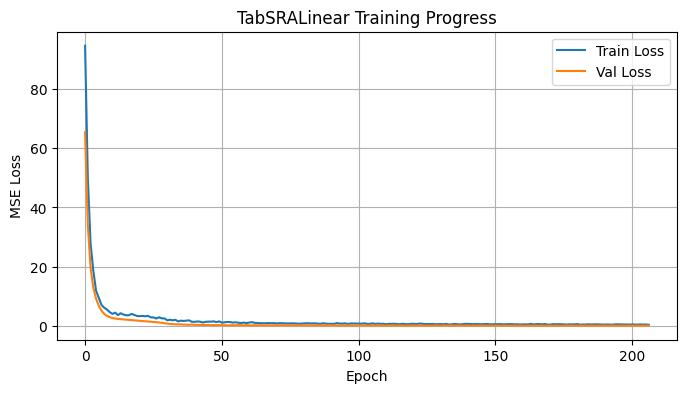

In [28]:
tabsra_optimizer = optim.AdamW(tabsra_model.parameters(), lr=1e-3, weight_decay=1e-4)
tabsra_scheduler = optim.lr_scheduler.CosineAnnealingLR(tabsra_optimizer, T_max=300, eta_min=1e-6)
criterion = nn.MSELoss()

# self-contained fallback: define set_seed/SEED here too, in case this section is run
# without first running Cell 4 (torch setup) earlier in the session
if 'SEED' not in globals():
    SEED = 42
if 'set_seed' not in globals():
    import random
    def set_seed(seed=SEED):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
best_val_loss = float("inf")
patience, patience_counter = 40, 0   # matches the paper's early-stopping round for TabSRALinear
tabsra_train_losses, tabsra_val_losses = [], []

for epoch in range(300):
    tabsra_model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred, _ = tabsra_model(X_batch)
        loss = criterion(y_pred, y_batch)
        tabsra_optimizer.zero_grad()
        loss.backward()
        tabsra_optimizer.step()
        epoch_loss += loss.item()
    tabsra_train_losses.append(epoch_loss / len(train_loader))

    tabsra_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred, _ = tabsra_model(X_batch)
            val_loss += criterion(y_pred, y_batch).item()
    val_loss /= len(val_loader)
    tabsra_val_losses.append(val_loss)
    tabsra_scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss, patience_counter = val_loss, 0
        torch.save(tabsra_model.state_dict(), "best_tabsra.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: train_loss={tabsra_train_losses[-1]:.4f}  val_loss={val_loss:.4f}")

tabsra_model.load_state_dict(torch.load("best_tabsra.pt"))
tabsra_model.eval()

plt.figure(figsize=(8, 4))
plt.plot(tabsra_train_losses, label="Train Loss")
plt.plot(tabsra_val_losses, label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.legend(); plt.grid()
plt.title("TabSRALinear Training Progress")
plt.show()


In [29]:
X_test_t = X_test.to(device) if isinstance(X_test, torch.Tensor) else torch.tensor(X_test_np, dtype=torch.float32, device=device)
y_test_t = y_test.to(device) if isinstance(y_test, torch.Tensor) else torch.tensor(y_test_np, dtype=torch.float32, device=device)

with torch.no_grad():
    y_tabsra_preds, _ = tabsra_model(X_test_t)
y_tabsra_preds_np = y_tabsra_preds.cpu().numpy()
y_test_for_compare = y_test_t.cpu().numpy()

tabsra_mse = mean_squared_error(y_test_for_compare, y_tabsra_preds_np)
tabsra_mae = mean_absolute_error(y_test_for_compare, y_tabsra_preds_np)
tabsra_r2 = r2_score(y_test_for_compare, y_tabsra_preds_np)

print("=" * 60)
print("TabSRALinear TEST SET RESULTS")
print("=" * 60)
print(f"MSE: {tabsra_mse:.4f}")
print(f"MAE: {tabsra_mae:.4f}")
print(f"R\u00b2 Score: {tabsra_r2:.4f}")

print("\n" + "=" * 60)
print("All models compared")
print("=" * 60)
print(f"{'Model':20s} {'R\u00b2':>10s} {'MAE':>10s} {'MSE':>10s}")
print(f"{'Linear Regression':20s} {0.9713:10.4f} {'-':>10s} {'-':>10s}")
print(f"{'XGBoost':20s} {0.9867:10.4f} {'-':>10s} {'-':>10s}")
print(f"{'iLTM':20s} {iltm_r2:10.4f} {iltm_mae:10.4f} {iltm_mse:10.4f}")
print(f"{'StablePFN':20s} {test_r2:10.4f} {test_mae:10.4f} {test_mse:10.4f}")
print(f"{'TabSRALinear':20s} {tabsra_r2:10.4f} {tabsra_mae:10.4f} {tabsra_mse:10.4f}")


TabSRALinear TEST SET RESULTS
MSE: 0.1609
MAE: 0.2966
R² Score: 0.9357

All models compared
Model                        R²        MAE        MSE
Linear Regression        0.9713          -          -
XGBoost                  0.9867          -          -
iLTM                     0.9730     0.1796     0.0675
StablePFN                0.7970     0.5909     0.5080
TabSRALinear             0.9357     0.2966     0.1609


Max reconstruction error (should be ~0): 0.000001

TabSRALinear -- EXACT Global Feature Importance
Sleep_Hours_Per_Night              : 1.2602
Country                            : 1.1484
Avg_Daily_Usage_Hours              : 0.9951
Conflicts_Over_Social_Media        : 0.7504
Mental_Health_Score                : 0.7049
Affects_Academic_Performance       : 0.2710
Age                                : 0.2248
Academic_Level                     : 0.2097
Platform_Instagram                 : 0.1902
Platform_TikTok                    : 0.1667
Relationship_Status                : 0.0587
Platform_Facebook                  : 0.0286
Platform_WhatsApp                  : 0.0148
Platform_LINE                      : 0.0068
Platform_Snapchat                  : 0.0054
Platform_WeChat                    : 0.0052
Platform_Twitter                   : 0.0046
Platform_YouTube                   : 0.0044
Platform_KakaoTalk                 : 0.0041
Gender                             : 0.0036
Platform_LinkedIn    

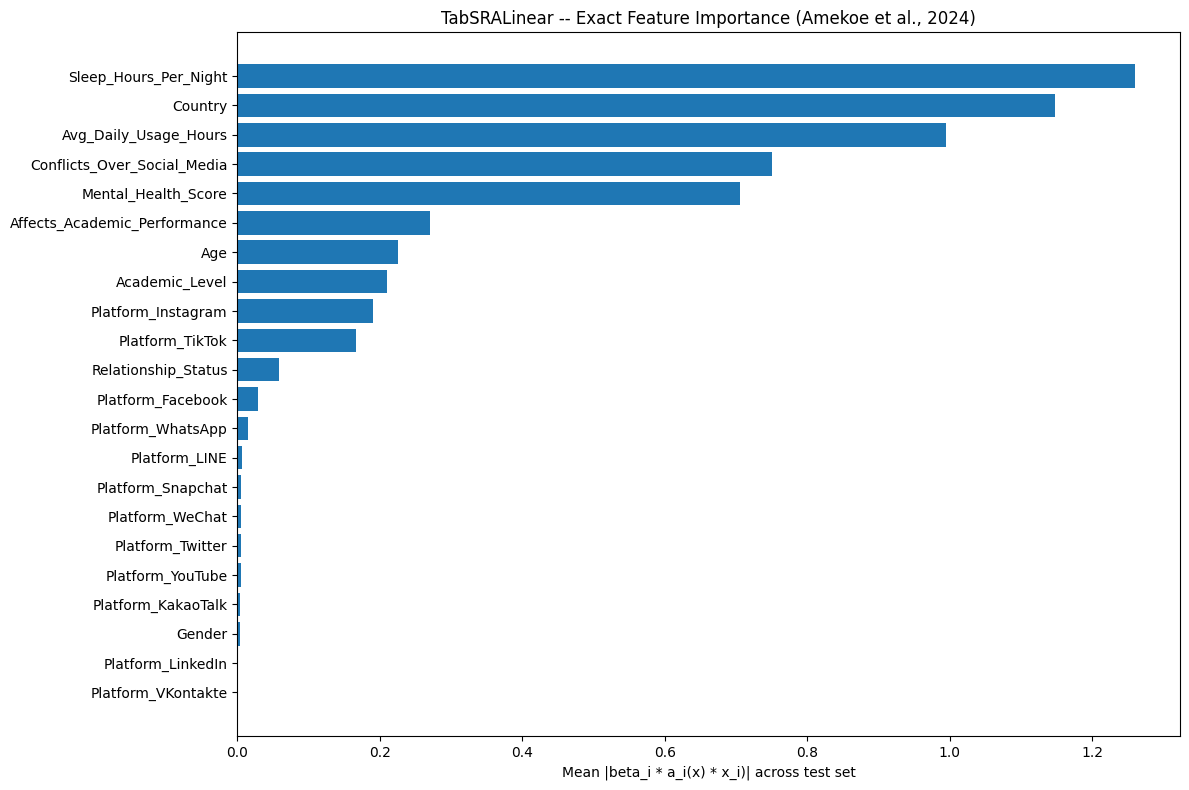

In [30]:
contributions = tabsra_model.feature_contributions(X_test_t).cpu().numpy()   # (n_test, n_features)

# Sanity check: contributions should sum (plus bias) to ~ the prediction
bias_total = sum(b.bias.item() if b.bias is not None else 0.0 for b in tabsra_model.beta)
reconstructed = contributions.sum(axis=1) + bias_total
print(f"Max reconstruction error (should be ~0): {np.abs(reconstructed - y_tabsra_preds_np).max():.6f}")

mean_abs_importance = np.abs(contributions).mean(axis=0)
order = np.argsort(-mean_abs_importance)

print("\n" + "=" * 60)
print("TabSRALinear -- EXACT Global Feature Importance")
print("=" * 60)
for i in order:
    print(f"{feature_names_list[i]:35s}: {mean_abs_importance[i]:.4f}")

plt.figure(figsize=(12, 8))
feats_sorted = [feature_names_list[i] for i in order]
vals_sorted = mean_abs_importance[order]
plt.barh(feats_sorted, vals_sorted)
plt.xlabel("Mean |beta_i * a_i(x) * x_i)| across test set")
plt.title("TabSRALinear -- Exact Feature Importance (Amekoe et al., 2024)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [31]:
import numpy as np

local_path = '/content/sma10_processed.npz'
data = np.load(local_path)

# Get numpy arrays (NOT torch tensors) for sklearn models
X_train_array = data['X_train'].astype(np.float32)
X_val_array = data['X_val'].astype(np.float32)
X_test_array = data['X_test'].astype(np.float32)

y_train_array = data['y_train'].astype(np.float32)
y_val_array = data['y_val'].astype(np.float32)
y_test_array = data['y_test'].astype(np.float32)

print(f"Data shapes:")
print(f"  X_train: {X_train_array.shape}, y_train: {y_train_array.shape}")
print(f"  X_val: {X_val_array.shape}, y_val: {y_val_array.shape}")
print(f"  X_test: {X_test_array.shape}, y_test: {y_test_array.shape}\n")

Data shapes:
  X_train: (493, 22), y_train: (493,)
  X_val: (71, 22), y_val: (71,)
  X_test: (141, 22), y_test: (141,)



In [34]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

#Decision Tree base and Tuned
print("="*80)
print("TRAINING DECISION TREE")
print("="*80)

# Base Decision Tree
dt_base = DecisionTreeRegressor(random_state=42)
dt_base.fit(X_train_array, y_train_array)
dt_base_pred = dt_base.predict(X_test_array)

dt_base_mse = mean_squared_error(y_test_array, dt_base_pred)
dt_base_mae = mean_absolute_error(y_test_array, dt_base_pred)
dt_base_r2 = r2_score(y_test_array, dt_base_pred)
dt_base_rmse = np.sqrt(dt_base_mse)

print("\nDecision Tree (Base - Default Parameters):")
print(f"  R² Score: {dt_base_r2:.4f}")
print(f"  RMSE: {dt_base_rmse:.4f}")
print(f"  MAE: {dt_base_mae:.4f}")
print(f"  MSE: {dt_base_mse:.4f}")

# Tuned Decision Tree with GridSearchCV
print("\nTuning Decision Tree with GridSearchCV...")
dt_param_grid = {
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'splitter': ['best', 'random']
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
dt_grid.fit(X_train_array, y_train_array)

dt_tuned = dt_grid.best_estimator_
dt_tuned_pred = dt_tuned.predict(X_test_array)

dt_tuned_mse = mean_squared_error(y_test_array, dt_tuned_pred)
dt_tuned_mae = mean_absolute_error(y_test_array, dt_tuned_pred)
dt_tuned_r2 = r2_score(y_test_array, dt_tuned_pred)
dt_tuned_rmse = np.sqrt(dt_tuned_mse)

print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Best CV Score: {dt_grid.best_score_:.4f}")
print("\nDecision Tree (Tuned):")
print(f"  R² Score: {dt_tuned_r2:.4f}")
print(f"  RMSE: {dt_tuned_rmse:.4f}")
print(f"  MAE: {dt_tuned_mae:.4f}")
print(f"  MSE: {dt_tuned_mse:.4f}")

TRAINING DECISION TREE

Decision Tree (Base - Default Parameters):
  R² Score: 0.9830
  RMSE: 0.2063
  MAE: 0.0426
  MSE: 0.0426

Tuning Decision Tree with GridSearchCV...
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
Best CV Score: 0.9837

Decision Tree (Tuned):
  R² Score: 0.9717
  RMSE: 0.2663
  MAE: 0.0709
  MSE: 0.0709


In [36]:
import numpy as np

from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
#Support Vector Machine (SVM) - Base and Tuned
print("\n" + "="*80)
print("TRAINING SUPPORT VECTOR MACHINE (SVM)")
print("="*80)

# Base SVM
svm_base = SVR(kernel='rbf')
svm_base.fit(X_train_array, y_train_array)
svm_base_pred = svm_base.predict(X_test_array)

svm_base_mse = mean_squared_error(y_test_array, svm_base_pred)
svm_base_mae = mean_absolute_error(y_test_array, svm_base_pred)
svm_base_r2 = r2_score(y_test_array, svm_base_pred)
svm_base_rmse = np.sqrt(svm_base_mse)

print("\nSVM (Base - RBF kernel):")
print(f"  R² Score: {svm_base_r2:.4f}")
print(f"  RMSE: {svm_base_rmse:.4f}")
print(f"  MAE: {svm_base_mae:.4f}")
print(f"  MSE: {svm_base_mse:.4f}")

# Tuned SVM with RandomizedSearchCV
print("\nTuning SVM with RandomizedSearchCV...")
svm_param_dist = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

svm_random = RandomizedSearchCV(
    SVR(),
    svm_param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=0
)
svm_random.fit(X_train_array, y_train_array)

svm_tuned = svm_random.best_estimator_
svm_tuned_pred = svm_tuned.predict(X_test_array)

svm_tuned_mse = mean_squared_error(y_test_array, svm_tuned_pred)
svm_tuned_mae = mean_absolute_error(y_test_array, svm_tuned_pred)
svm_tuned_r2 = r2_score(y_test_array, svm_tuned_pred)
svm_tuned_rmse = np.sqrt(svm_tuned_mse)

print(f"Best Parameters: {svm_random.best_params_}")
print(f"Best CV Score: {svm_random.best_score_:.4f}")
print("\nSVM (Tuned):")
print(f"  R² Score: {svm_tuned_r2:.4f}")
print(f"  RMSE: {svm_tuned_rmse:.4f}")
print(f"  MAE: {svm_tuned_mae:.4f}")
print(f"  MSE: {svm_tuned_mse:.4f}")



TRAINING SUPPORT VECTOR MACHINE (SVM)

SVM (Base - RBF kernel):
  R² Score: 0.9566
  RMSE: 0.3297
  MAE: 0.2663
  MSE: 0.1087

Tuning SVM with RandomizedSearchCV...
Best Parameters: {'kernel': 'rbf', 'gamma': 0.01, 'epsilon': 0.01, 'C': 100}
Best CV Score: 0.9780

SVM (Tuned):
  R² Score: 0.9837
  RMSE: 0.2020
  MAE: 0.1114
  MSE: 0.0408


In [38]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Linear Regression - Base and Tuned
print("\n" + "="*80)
print("TRAINING LINEAR REGRESSION")
print("="*80)

# Base Linear Regression
lr_base = LinearRegression()
lr_base.fit(X_train_array, y_train_array)
lr_base_pred = lr_base.predict(X_test_array)

lr_base_mse = mean_squared_error(y_test_array, lr_base_pred)
lr_base_mae = mean_absolute_error(y_test_array, lr_base_pred)
lr_base_r2 = r2_score(y_test_array, lr_base_pred)
lr_base_rmse = np.sqrt(lr_base_mse)

print("\nLinear Regression (Base):")
print(f"  R² Score: {lr_base_r2:.4f}")
print(f"  RMSE: {lr_base_rmse:.4f}")
print(f"  MAE: {lr_base_mae:.4f}")
print(f"  MSE: {lr_base_mse:.4f}")

# Tuned Linear Regression (Ridge) with GridSearchCV
print("\nTuning Linear Regression (Ridge) with GridSearchCV...")
lr_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

lr_grid = GridSearchCV(
    Ridge(),
    lr_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
lr_grid.fit(X_train_array, y_train_array)

lr_tuned = lr_grid.best_estimator_
lr_tuned_pred = lr_tuned.predict(X_test_array)

lr_tuned_mse = mean_squared_error(y_test_array, lr_tuned_pred)
lr_tuned_mae = mean_absolute_error(y_test_array, lr_tuned_pred)
lr_tuned_r2 = r2_score(y_test_array, lr_tuned_pred)
lr_tuned_rmse = np.sqrt(lr_tuned_mse)

print(f"Best Parameters: {lr_grid.best_params_}")
print(f"Best CV Score: {lr_grid.best_score_:.4f}")
print("\nLinear Regression (Tuned - Ridge):")
print(f"  R² Score: {lr_tuned_r2:.4f}")
print(f"  RMSE: {lr_tuned_rmse:.4f}")
print(f"  MAE: {lr_tuned_mae:.4f}")
print(f"  MSE: {lr_tuned_mse:.4f}")


TRAINING LINEAR REGRESSION

Linear Regression (Base):
  R² Score: 0.9713
  RMSE: 0.2679
  MAE: 0.2102
  MSE: 0.0718

Tuning Linear Regression (Ridge) with GridSearchCV...
Best Parameters: {'alpha': 0.1}
Best CV Score: 0.9721

Linear Regression (Tuned - Ridge):
  R² Score: 0.9715
  RMSE: 0.2671
  MAE: 0.2100
  MSE: 0.0714


In [40]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Random Forest - Base and Tuned
print("\n" + "="*80)
print("TRAINING RANDOM FOREST")
print("="*80)

# Base Random Forest
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train_array, y_train_array)
rf_base_pred = rf_base.predict(X_test_array)

rf_base_mse = mean_squared_error(y_test_array, rf_base_pred)
rf_base_mae = mean_absolute_error(y_test_array, rf_base_pred)
rf_base_r2 = r2_score(y_test_array, rf_base_pred)
rf_base_rmse = np.sqrt(rf_base_mse)

print("\nRandom Forest (Base - 100 estimators):")
print(f"  R² Score: {rf_base_r2:.4f}")
print(f"  RMSE: {rf_base_rmse:.4f}")
print(f"  MAE: {rf_base_mae:.4f}")
print(f"  MSE: {rf_base_mse:.4f}")

# Tuned Random Forest with GridSearchCV
print("\nTuning Random Forest with GridSearchCV...")
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train_array, y_train_array)

rf_tuned = rf_grid.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test_array)

rf_tuned_mse = mean_squared_error(y_test_array, rf_tuned_pred)
rf_tuned_mae = mean_absolute_error(y_test_array, rf_tuned_pred)
rf_tuned_r2 = r2_score(y_test_array, rf_tuned_pred)
rf_tuned_rmse = np.sqrt(rf_tuned_mse)

print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Best CV Score: {rf_grid.best_score_:.4f}")
print("\nRandom Forest (Tuned):")
print(f"  R² Score: {rf_tuned_r2:.4f}")
print(f"  RMSE: {rf_tuned_rmse:.4f}")
print(f"  MAE: {rf_tuned_mae:.4f}")
print(f"  MSE: {rf_tuned_mse:.4f}")


TRAINING RANDOM FOREST

Random Forest (Base - 100 estimators):
  R² Score: 0.9888
  RMSE: 0.1671
  MAE: 0.0552
  MSE: 0.0279

Tuning Random Forest with GridSearchCV...
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9845

Random Forest (Tuned):
  R² Score: 0.9868
  RMSE: 0.1814
  MAE: 0.0862
  MSE: 0.0329


In [41]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Gradient Boosting - Base and Tuned
print("\n" + "="*80)
print("TRAINING GRADIENT BOOSTING")
print("="*80)

# Base Gradient Boosting
gb_base = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_base.fit(X_train_array, y_train_array)
gb_base_pred = gb_base.predict(X_test_array)

gb_base_mse = mean_squared_error(y_test_array, gb_base_pred)
gb_base_mae = mean_absolute_error(y_test_array, gb_base_pred)
gb_base_r2 = r2_score(y_test_array, gb_base_pred)
gb_base_rmse = np.sqrt(gb_base_mse)

print("\nGradient Boosting (Base):")
print(f"  R² Score: {gb_base_r2:.4f}")
print(f"  RMSE: {gb_base_rmse:.4f}")
print(f"  MAE: {gb_base_mae:.4f}")
print(f"  MSE: {gb_base_mse:.4f}")

# Tuned Gradient Boosting with GridSearchCV
print("\nTuning Gradient Boosting with GridSearchCV...")
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
gb_grid.fit(X_train_array, y_train_array)

gb_tuned = gb_grid.best_estimator_
gb_tuned_pred = gb_tuned.predict(X_test_array)

gb_tuned_mse = mean_squared_error(y_test_array, gb_tuned_pred)
gb_tuned_mae = mean_absolute_error(y_test_array, gb_tuned_pred)
gb_tuned_r2 = r2_score(y_test_array, gb_tuned_pred)
gb_tuned_rmse = np.sqrt(gb_tuned_mse)

print(f"Best Parameters: {gb_grid.best_params_}")
print(f"Best CV Score: {gb_grid.best_score_:.4f}")
print("\nGradient Boosting (Tuned):")
print(f"  R² Score: {gb_tuned_r2:.4f}")
print(f"  RMSE: {gb_tuned_rmse:.4f}")
print(f"  MAE: {gb_tuned_mae:.4f}")
print(f"  MSE: {gb_tuned_mse:.4f}")


TRAINING GRADIENT BOOSTING

Gradient Boosting (Base):
  R² Score: 0.9822
  RMSE: 0.2110
  MAE: 0.1131
  MSE: 0.0445

Tuning Gradient Boosting with GridSearchCV...
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9888

Gradient Boosting (Tuned):
  R² Score: 0.9850
  RMSE: 0.1937
  MAE: 0.0720
  MSE: 0.0375


In [42]:
import numpy as np
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# AdaBoost - Base and Tuned
print("\n" + "="*80)
print("TRAINING ADABOOST")
print("="*80)

# Base AdaBoost
ada_base = AdaBoostRegressor(n_estimators=100, random_state=42)
ada_base.fit(X_train_array, y_train_array)
ada_base_pred = ada_base.predict(X_test_array)

ada_base_mse = mean_squared_error(y_test_array, ada_base_pred)
ada_base_mae = mean_absolute_error(y_test_array, ada_base_pred)
ada_base_r2 = r2_score(y_test_array, ada_base_pred)
ada_base_rmse = np.sqrt(ada_base_mse)

print("\nAdaBoost (Base):")
print(f"  R² Score: {ada_base_r2:.4f}")
print(f"  RMSE: {ada_base_rmse:.4f}")
print(f"  MAE: {ada_base_mae:.4f}")
print(f"  MSE: {ada_base_mse:.4f}")

# Tuned AdaBoost with GridSearchCV
print("\nTuning AdaBoost with GridSearchCV...")
ada_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.001, 0.01, 0.1, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

ada_grid = GridSearchCV(
    AdaBoostRegressor(random_state=42),
    ada_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
ada_grid.fit(X_train_array, y_train_array)

ada_tuned = ada_grid.best_estimator_
ada_tuned_pred = ada_tuned.predict(X_test_array)

ada_tuned_mse = mean_squared_error(y_test_array, ada_tuned_pred)
ada_tuned_mae = mean_absolute_error(y_test_array, ada_tuned_pred)
ada_tuned_r2 = r2_score(y_test_array, ada_tuned_pred)
ada_tuned_rmse = np.sqrt(ada_tuned_mse)

print(f"Best Parameters: {ada_grid.best_params_}")
print(f"Best CV Score: {ada_grid.best_score_:.4f}")
print("\nAdaBoost (Tuned):")
print(f"  R² Score: {ada_tuned_r2:.4f}")
print(f"  RMSE: {ada_tuned_rmse:.4f}")
print(f"  MAE: {ada_tuned_mae:.4f}")
print(f"  MSE: {ada_tuned_mse:.4f}")


TRAINING ADABOOST

AdaBoost (Base):
  R² Score: 0.9644
  RMSE: 0.2985
  MAE: 0.2150
  MSE: 0.0891

Tuning AdaBoost with GridSearchCV...
Best Parameters: {'learning_rate': 0.01, 'loss': 'exponential', 'n_estimators': 200}
Best CV Score: 0.9658

AdaBoost (Tuned):
  R² Score: 0.9645
  RMSE: 0.2980
  MAE: 0.1669
  MSE: 0.0888


In [43]:
import numpy as np
from sklearn.ensemble import VotingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Voting Ensemble
print("\n" + "="*80)
print("TRAINING VOTING ENSEMBLE")
print("="*80)

voting = VotingRegressor(estimators=[
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ('lr', LinearRegression())
])
voting.fit(X_train_array, y_train_array)
voting_pred = voting.predict(X_test_array)

voting_mse = mean_squared_error(y_test_array, voting_pred)
voting_mae = mean_absolute_error(y_test_array, voting_pred)
voting_r2 = r2_score(y_test_array, voting_pred)
voting_rmse = np.sqrt(voting_mse)

print("\nVoting Ensemble (RF + GB + LR):")
print(f"  R² Score: {voting_r2:.4f}")
print(f"  RMSE: {voting_rmse:.4f}")
print(f"  MAE: {voting_mae:.4f}")
print(f"  MSE: {voting_mse:.4f}")


TRAINING VOTING ENSEMBLE

Voting Ensemble (RF + GB + LR):
  R² Score: 0.9856
  RMSE: 0.1898
  MAE: 0.1223
  MSE: 0.0360


In [44]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Stacking Regressor
print("\n" + "="*80)
print("TRAINING STACKING REGRESSOR")
print("="*80)

class StackingRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, base_models, meta_model):
        self.base_models = base_models
        self.meta_model = meta_model
        self.trained_base_models = []

    def fit(self, X, y):
        meta_features = []
        for name, model in self.base_models:
            model.fit(X, y)
            self.trained_base_models.append((name, model))
            base_pred = model.predict(X)
            meta_features.append(base_pred)
        X_meta = np.column_stack(meta_features)
        self.meta_model.fit(X_meta, y)
        return self

    def predict(self, X):
        meta_features = []
        for name, model in self.trained_base_models:
            base_pred = model.predict(X)
            meta_features.append(base_pred)
        X_meta = np.column_stack(meta_features)
        return self.meta_model.predict(X_meta)

stacking = StackingRegressor(
    base_models=[
        ('dt', DecisionTreeRegressor(max_depth=15, random_state=42)),
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42))
    ],
    meta_model=LinearRegression()
)
stacking.fit(X_train_array, y_train_array)
stacking_pred = stacking.predict(X_test_array)

stacking_mse = mean_squared_error(y_test_array, stacking_pred)
stacking_mae = mean_absolute_error(y_test_array, stacking_pred)
stacking_r2 = r2_score(y_test_array, stacking_pred)
stacking_rmse = np.sqrt(stacking_mse)

print("\nStacking Regressor (DT + RF + GB, Meta: LR):")
print(f"  R² Score: {stacking_r2:.4f}")
print(f"  RMSE: {stacking_rmse:.4f}")
print(f"  MAE: {stacking_mae:.4f}")
print(f"  MSE: {stacking_mse:.4f}")


TRAINING STACKING REGRESSOR

Stacking Regressor (DT + RF + GB, Meta: LR):
  R² Score: 0.9830
  RMSE: 0.2063
  MAE: 0.0426
  MSE: 0.0426


In [45]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Blending Regressor
print("\n" + "="*80)
print("TRAINING BLENDING REGRESSOR")
print("="*80)

class BlendingRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, base_models, meta_model, validation_split=0.2):
        self.base_models = base_models
        self.meta_model = meta_model
        self.validation_split = validation_split
        self.trained_base_models = []

    def fit(self, X, y):
        split_idx = int(len(X) * (1 - self.validation_split))
        X_train_split, X_blend = X[:split_idx], X[split_idx:]
        y_train_split, y_blend = y[:split_idx], y[split_idx:]

        meta_features = []
        for name, model in self.base_models:
            model.fit(X_train_split, y_train_split)
            self.trained_base_models.append((name, model))
            blend_pred = model.predict(X_blend)
            meta_features.append(blend_pred)

        X_meta = np.column_stack(meta_features)
        self.meta_model.fit(X_meta, y_blend)
        return self

    def predict(self, X):
        meta_features = []
        for name, model in self.trained_base_models:
            base_pred = model.predict(X)
            meta_features.append(base_pred)
        X_meta = np.column_stack(meta_features)
        return self.meta_model.predict(X_meta)

blending = BlendingRegressor(
    base_models=[
        ('dt', DecisionTreeRegressor(max_depth=15, random_state=42)),
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42))
    ],
    meta_model=Ridge(alpha=1.0),
    validation_split=0.2
)
blending.fit(X_train_array, y_train_array)
blending_pred = blending.predict(X_test_array)

blending_mse = mean_squared_error(y_test_array, blending_pred)
blending_mae = mean_absolute_error(y_test_array, blending_pred)
blending_r2 = r2_score(y_test_array, blending_pred)
blending_rmse = np.sqrt(blending_mse)

print("\nBlending Regressor (DT + RF + GB, Meta: Ridge):")
print(f"  R² Score: {blending_r2:.4f}")
print(f"  RMSE: {blending_rmse:.4f}")
print(f"  MAE: {blending_mae:.4f}")
print(f"  MSE: {blending_mse:.4f}")


TRAINING BLENDING REGRESSOR

Blending Regressor (DT + RF + GB, Meta: Ridge):
  R² Score: 0.9872
  RMSE: 0.1793
  MAE: 0.0890
  MSE: 0.0322


In [69]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

print("=" * 80)
print("DATA AUGMENTATION: SMOTE ON TRAINING DATA")
print("=" * 80)

# Convert tensors/Series to numpy if needed
if hasattr(y_train, 'detach'):
    X_train_np = X_train.detach().cpu().numpy() if hasattr(X_train, 'detach') else np.array(X_train)
    y_train_np = y_train.detach().cpu().numpy() if hasattr(y_train, 'detach') else np.array(y_train)
else:
    X_train_np = np.array(X_train)
    y_train_np = np.array(y_train)

if hasattr(y_test, 'detach'):
    X_test_np = X_test.detach().cpu().numpy() if hasattr(X_test, 'detach') else np.array(X_test)
    y_test_np = y_test.detach().cpu().numpy() if hasattr(y_test, 'detach') else np.array(y_test)
else:
    X_test_np = np.array(X_test)
    y_test_np = np.array(y_test)

# Create binary labels (same threshold as your ML models)
y_train_binary = (y_train_np >= 6).astype(int)
y_test_binary = (y_test_np >= 6).astype(int)

print(f"\nOriginal training set class distribution:")
print(f"  Not Addicted (0): {(y_train_binary == 0).sum()}")
print(f"  Addicted (1):     {(y_train_binary == 1).sum()}")

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_augmented, y_train_augmented = smote.fit_resample(X_train_np, y_train_binary)

print(f"\nAfter SMOTE augmentation:")
print(f"  Not Addicted (0): {(y_train_augmented == 0).sum()}")
print(f"  Addicted (1):     {(y_train_augmented == 1).sum()}")

# Scale features
scaler = StandardScaler()
X_train_aug_scaled = scaler.fit_transform(X_train_augmented)
X_test_scaled = scaler.transform(X_test_np)

# ============================================================================
# RETRAIN ALL ML MODELS ON AUGMENTED DATA
# ============================================================================

print("\nRetraining all models on SMOTE-augmented data...\n")

aug_results = []

# 1. Decision Tree
dt_aug = DecisionTreeClassifier(random_state=42)
dt_aug.fit(X_train_augmented, y_train_augmented)
dt_aug_pred = dt_aug.predict(X_test_np)
aug_results.append({
    'Model': 'Decision Tree (SMOTE)',
    'Accuracy': accuracy_score(y_test_binary, dt_aug_pred),
    'Precision': precision_score(y_test_binary, dt_aug_pred, zero_division=0),
    'Recall': recall_score(y_test_binary, dt_aug_pred, zero_division=0),
    'F1': f1_score(y_test_binary, dt_aug_pred, zero_division=0),
})

# 2. SVM
svm_aug = SVC(kernel='rbf', random_state=42)
svm_aug.fit(X_train_aug_scaled, y_train_augmented)
svm_aug_pred = svm_aug.predict(X_test_scaled)
aug_results.append({
    'Model': 'SVM (SMOTE)',
    'Accuracy': accuracy_score(y_test_binary, svm_aug_pred),
    'Precision': precision_score(y_test_binary, svm_aug_pred, zero_division=0),
    'Recall': recall_score(y_test_binary, svm_aug_pred, zero_division=0),
    'F1': f1_score(y_test_binary, svm_aug_pred, zero_division=0),
})

# 3. Logistic Regression
lr_aug = LogisticRegression(random_state=42, max_iter=200)
lr_aug.fit(X_train_aug_scaled, y_train_augmented)
lr_aug_pred = lr_aug.predict(X_test_scaled)
aug_results.append({
    'Model': 'Logistic Regression (SMOTE)',
    'Accuracy': accuracy_score(y_test_binary, lr_aug_pred),
    'Precision': precision_score(y_test_binary, lr_aug_pred, zero_division=0),
    'Recall': recall_score(y_test_binary, lr_aug_pred, zero_division=0),
    'F1': f1_score(y_test_binary, lr_aug_pred, zero_division=0),
})

# 4. Random Forest
rf_aug = RandomForestClassifier(n_estimators=100, random_state=42)
rf_aug.fit(X_train_augmented, y_train_augmented)
rf_aug_pred = rf_aug.predict(X_test_np)
aug_results.append({
    'Model': 'Random Forest (SMOTE)',
    'Accuracy': accuracy_score(y_test_binary, rf_aug_pred),
    'Precision': precision_score(y_test_binary, rf_aug_pred, zero_division=0),
    'Recall': recall_score(y_test_binary, rf_aug_pred, zero_division=0),
    'F1': f1_score(y_test_binary, rf_aug_pred, zero_division=0),
})

# 5. Gradient Boosting
gb_aug = GradientBoostingClassifier(random_state=42)
gb_aug.fit(X_train_augmented, y_train_augmented)
gb_aug_pred = gb_aug.predict(X_test_np)
aug_results.append({
    'Model': 'Gradient Boosting (SMOTE)',
    'Accuracy': accuracy_score(y_test_binary, gb_aug_pred),
    'Precision': precision_score(y_test_binary, gb_aug_pred, zero_division=0),
    'Recall': recall_score(y_test_binary, gb_aug_pred, zero_division=0),
    'F1': f1_score(y_test_binary, gb_aug_pred, zero_division=0),
})

# 6. AdaBoost
ada_aug = AdaBoostClassifier(random_state=42)
ada_aug.fit(X_train_augmented, y_train_augmented)
ada_aug_pred = ada_aug.predict(X_test_np)
aug_results.append({
    'Model': 'AdaBoost (SMOTE)',
    'Accuracy': accuracy_score(y_test_binary, ada_aug_pred),
    'Precision': precision_score(y_test_binary, ada_aug_pred, zero_division=0),
    'Recall': recall_score(y_test_binary, ada_aug_pred, zero_division=0),
    'F1': f1_score(y_test_binary, ada_aug_pred, zero_division=0),
})

# 7. Voting Ensemble
voting_aug = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42)),
    ]
)
voting_aug.fit(X_train_augmented, y_train_augmented)
voting_aug_pred = voting_aug.predict(X_test_np)
aug_results.append({
    'Model': 'Voting Ensemble (SMOTE)',
    'Accuracy': accuracy_score(y_test_binary, voting_aug_pred),
    'Precision': precision_score(y_test_binary, voting_aug_pred, zero_division=0),
    'Recall': recall_score(y_test_binary, voting_aug_pred, zero_division=0),
    'F1': f1_score(y_test_binary, voting_aug_pred, zero_division=0),
})

# ============================================================================
# RESULTS TABLE
# ============================================================================

aug_df = pd.DataFrame(aug_results).set_index('Model')
aug_df = aug_df[['Accuracy', 'Precision', 'Recall', 'F1']].round(4)
aug_df = aug_df.sort_values('F1', ascending=False)

print("=" * 80)
print("MODELS TRAINED ON SMOTE-AUGMENTED DATA")
print("=" * 80)
print(aug_df.to_string())

# Save results
aug_df.to_csv('models_smote_augmented_results.csv')
print("\n✓ Saved: models_smote_augmented_results.csv")

DATA AUGMENTATION: SMOTE ON TRAINING DATA

Original training set class distribution:
  Not Addicted (0): 162
  Addicted (1):     331

After SMOTE augmentation:
  Not Addicted (0): 331
  Addicted (1):     331

Retraining all models on SMOTE-augmented data...

MODELS TRAINED ON SMOTE-AUGMENTED DATA
                             Accuracy  Precision  Recall      F1
Model                                                           
Logistic Regression (SMOTE)    1.0000     1.0000  1.0000  1.0000
Random Forest (SMOTE)          1.0000     1.0000  1.0000  1.0000
Decision Tree (SMOTE)          0.9929     0.9888  1.0000  0.9944
AdaBoost (SMOTE)               0.9929     0.9888  1.0000  0.9944
Gradient Boosting (SMOTE)      0.9929     0.9888  1.0000  0.9944
Voting Ensemble (SMOTE)        0.9929     0.9888  1.0000  0.9944
SVM (SMOTE)                    0.9929     1.0000  0.9886  0.9943

✓ Saved: models_smote_augmented_results.csv


In [46]:
import pandas as pd

# Comparison Table
print("\n" + "="*80)
print("TRADITIONAL ML MODELS - COMPARISON TABLE")
print("="*80)

ml_results = {
    'Decision Tree (Base)': {'R2': dt_base_r2, 'RMSE': dt_base_rmse, 'MAE': dt_base_mae, 'MSE': dt_base_mse},
    'Decision Tree (Tuned)': {'R2': dt_tuned_r2, 'RMSE': dt_tuned_rmse, 'MAE': dt_tuned_mae, 'MSE': dt_tuned_mse},
    'SVM (Base)': {'R2': svm_base_r2, 'RMSE': svm_base_rmse, 'MAE': svm_base_mae, 'MSE': svm_base_mse},
    'SVM (Tuned)': {'R2': svm_tuned_r2, 'RMSE': svm_tuned_rmse, 'MAE': svm_tuned_mae, 'MSE': svm_tuned_mse},
    'Linear Regression (Base)': {'R2': lr_base_r2, 'RMSE': lr_base_rmse, 'MAE': lr_base_mae, 'MSE': lr_base_mse},
    'Linear Regression (Tuned)': {'R2': lr_tuned_r2, 'RMSE': lr_tuned_rmse, 'MAE': lr_tuned_mae, 'MSE': lr_tuned_mse},
    'Random Forest (Base)': {'R2': rf_base_r2, 'RMSE': rf_base_rmse, 'MAE': rf_base_mae, 'MSE': rf_base_mse},
    'Random Forest (Tuned)': {'R2': rf_tuned_r2, 'RMSE': rf_tuned_rmse, 'MAE': rf_tuned_mae, 'MSE': rf_tuned_mse},
    'Gradient Boosting (Base)': {'R2': gb_base_r2, 'RMSE': gb_base_rmse, 'MAE': gb_base_mae, 'MSE': gb_base_mse},
    'Gradient Boosting (Tuned)': {'R2': gb_tuned_r2, 'RMSE': gb_tuned_rmse, 'MAE': gb_tuned_mae, 'MSE': gb_tuned_mse},
    'AdaBoost (Base)': {'R2': ada_base_r2, 'RMSE': ada_base_rmse, 'MAE': ada_base_mae, 'MSE': ada_base_mse},
    'AdaBoost (Tuned)': {'R2': ada_tuned_r2, 'RMSE': ada_tuned_rmse, 'MAE': ada_tuned_mae, 'MSE': ada_tuned_mse},
    'Voting Ensemble': {'R2': voting_r2, 'RMSE': voting_rmse, 'MAE': voting_mae, 'MSE': voting_mse},
    'Stacking': {'R2': stacking_r2, 'RMSE': stacking_rmse, 'MAE': stacking_mae, 'MSE': stacking_mse},
    'Blending': {'R2': blending_r2, 'RMSE': blending_rmse, 'MAE': blending_mae, 'MSE': blending_mse},
}

ml_comparison_df = pd.DataFrame(ml_results).T
ml_comparison_df = ml_comparison_df[['R2', 'RMSE', 'MAE', 'MSE']].round(4)
ml_comparison_df = ml_comparison_df.sort_values('R2', ascending=False)
print(ml_comparison_df)


TRADITIONAL ML MODELS - COMPARISON TABLE
                               R2    RMSE     MAE     MSE
Random Forest (Base)       0.9888  0.1671  0.0552  0.0279
Blending                   0.9872  0.1793  0.0890  0.0322
Random Forest (Tuned)      0.9868  0.1814  0.0862  0.0329
Voting Ensemble            0.9856  0.1898  0.1223  0.0360
Gradient Boosting (Tuned)  0.9850  0.1937  0.0720  0.0375
SVM (Tuned)                0.9837  0.2020  0.1114  0.0408
Decision Tree (Base)       0.9830  0.2063  0.0426  0.0426
Stacking                   0.9830  0.2063  0.0426  0.0426
Gradient Boosting (Base)   0.9822  0.2110  0.1131  0.0445
Decision Tree (Tuned)      0.9717  0.2663  0.0709  0.0709
Linear Regression (Tuned)  0.9715  0.2671  0.2100  0.0714
Linear Regression (Base)   0.9713  0.2679  0.2102  0.0718
AdaBoost (Tuned)           0.9645  0.2980  0.1669  0.0888
AdaBoost (Base)            0.9644  0.2985  0.2150  0.0891
SVM (Base)                 0.9566  0.3297  0.2663  0.1087


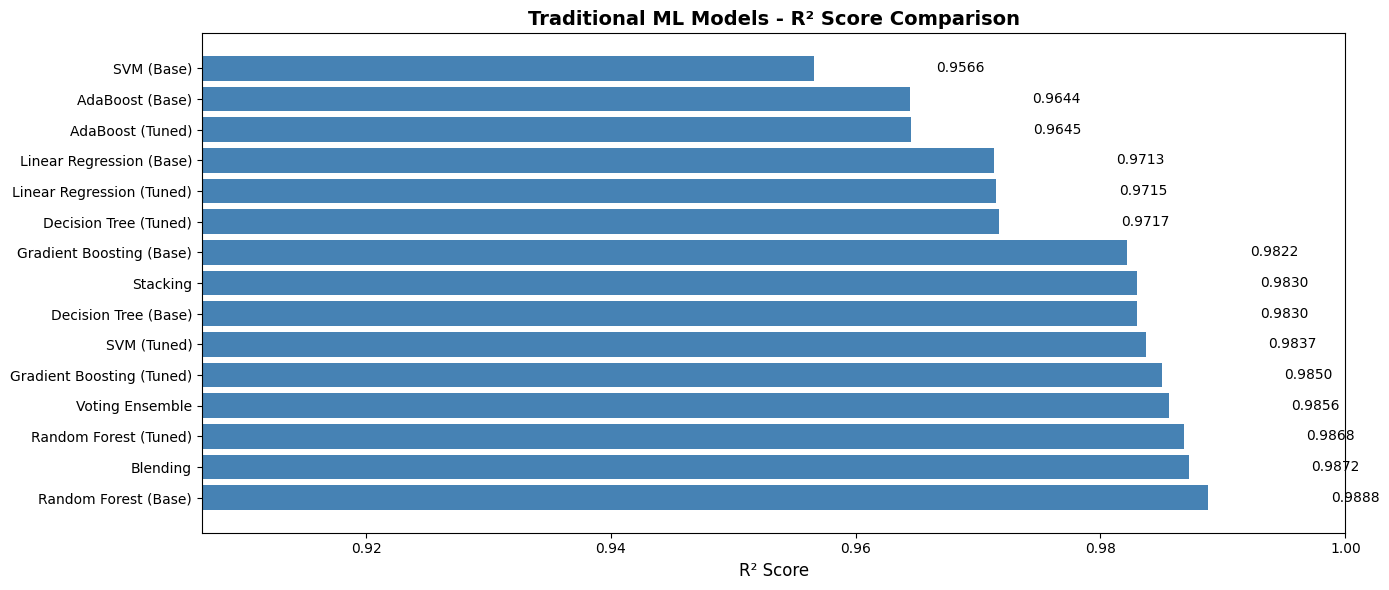

In [47]:
import matplotlib.pyplot as plt

# Plot Traditional ML Model Comparison
plt.figure(figsize=(14, 6))
plt.barh(ml_comparison_df.index, ml_comparison_df['R2'], color='steelblue')
plt.xlabel('R² Score', fontsize=12)
plt.title('Traditional ML Models - R² Score Comparison', fontsize=14, fontweight='bold')
plt.xlim([ml_comparison_df['R2'].min() - 0.05, 1.0])

for i, v in enumerate(ml_comparison_df['R2']):
    plt.text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()


HYPERPARAMETER TUNING IMPROVEMENT ANALYSIS

             Model  Improvement %
              SVM       2.838156
Gradient Boosting       0.283451
Linear Regression       0.017421
         AdaBoost       0.011440
    Random Forest      -0.201836
    Decision Tree      -1.153327


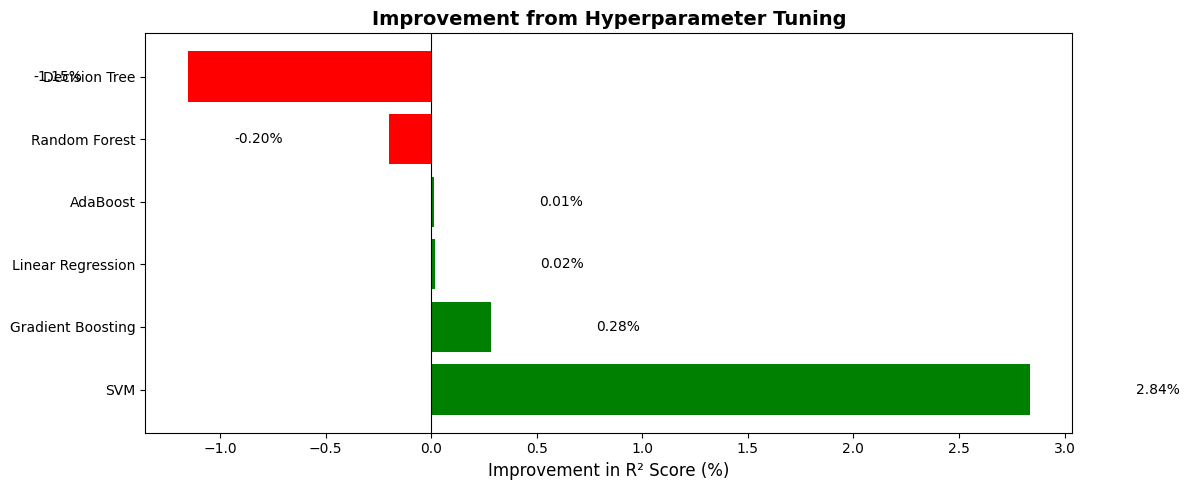


✓ Results saved to 'traditional_ml_comparison.csv'


In [48]:
#Improvement Analysis (Base vs Tuned)
print("\n" + "="*80)
print("HYPERPARAMETER TUNING IMPROVEMENT ANALYSIS")
print("="*80)

improvements = {
    'Decision Tree': ((dt_tuned_r2 - dt_base_r2) / abs(dt_base_r2) * 100) if dt_base_r2 != 0 else 0,
    'SVM': ((svm_tuned_r2 - svm_base_r2) / abs(svm_base_r2) * 100) if svm_base_r2 != 0 else 0,
    'Linear Regression': ((lr_tuned_r2 - lr_base_r2) / abs(lr_base_r2) * 100) if lr_base_r2 != 0 else 0,
    'Random Forest': ((rf_tuned_r2 - rf_base_r2) / abs(rf_base_r2) * 100) if rf_base_r2 != 0 else 0,
    'Gradient Boosting': ((gb_tuned_r2 - gb_base_r2) / abs(gb_base_r2) * 100) if gb_base_r2 != 0 else 0,
    'AdaBoost': ((ada_tuned_r2 - ada_base_r2) / abs(ada_base_r2) * 100) if ada_base_r2 != 0 else 0,
}

improvement_df = pd.DataFrame(list(improvements.items()), columns=['Model', 'Improvement %']).sort_values('Improvement %', ascending=False)
print("\n", improvement_df.to_string(index=False))

plt.figure(figsize=(12, 5))
colors = ['green' if x > 0 else 'red' for x in improvement_df['Improvement %']]
plt.barh(improvement_df['Model'], improvement_df['Improvement %'], color=colors)
plt.xlabel('Improvement in R² Score (%)', fontsize=12)
plt.title('Improvement from Hyperparameter Tuning', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
for i, v in enumerate(improvement_df['Improvement %']):
    plt.text(v + (0.5 if v > 0 else -0.5), i, f'{v:.2f}%', va='center', ha='left' if v > 0 else 'right')
plt.tight_layout()
plt.show()

# Save results
ml_comparison_df.to_csv('traditional_ml_comparison.csv')
print("\n✓ Results saved to 'traditional_ml_comparison.csv'")

In [49]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

THRESHOLD = 6.0  # Addicted_Score >= 6 counts as "Addicted" (matches the iLTM/TabSRA cells above)

def to_numpy(x):
    if x is None:
        return None
    if hasattr(x, "detach"):                                   # torch tensor
        return x.detach().cpu().numpy()
    if hasattr(x, "values") and not isinstance(x, np.ndarray):  # pandas Series/DataFrame
        return x.values
    return np.asarray(x)

# (display name, predictions variable, ground-truth variable) for every model in the notebook
model_pairs = [
    ("StablePFN",                 "y_test_preds",        "y_test_trues"),
    ("StablePFN (MB-masked)",     "y_test_preds_masked", "y_test_trues"),
    ("iLTM",                      "y_iltm_preds",         "y_test_np"),
    ("iLTM (no Country)",         "y_iltm_preds_nc",      "y_test_np"),
    ("iLTM (raw preprocessing)",  "y_iltm_preds_raw",     "y_test_raw"),
    ("XGBoost",                   "y_xgb_preds",          "y_test_np"),
    ("TabSRALinear",              "y_tabsra_preds_np",    "y_test_for_compare"),
    ("Decision Tree (Base)",      "dt_base_pred",         "y_test_array"),
    ("Decision Tree (Tuned)",     "dt_tuned_pred",        "y_test_array"),
    ("SVM (Base)",                "svm_base_pred",        "y_test_array"),
    ("SVM (Tuned)",               "svm_tuned_pred",       "y_test_array"),
    ("Linear Regression (Base)",  "lr_base_pred",         "y_test_array"),
    ("Linear Regression (Tuned)", "lr_tuned_pred",        "y_test_array"),
    ("Random Forest (Base)",      "rf_base_pred",         "y_test_array"),
    ("Random Forest (Tuned)",     "rf_tuned_pred",        "y_test_array"),
    ("Gradient Boosting (Base)",  "gb_base_pred",         "y_test_array"),
    ("Gradient Boosting (Tuned)", "gb_tuned_pred",        "y_test_array"),
    ("AdaBoost (Base)",           "ada_base_pred",        "y_test_array"),
    ("AdaBoost (Tuned)",          "ada_tuned_pred",       "y_test_array"),
    ("Voting Ensemble",           "voting_pred",          "y_test_array"),
    ("Stacking",                  "stacking_pred",        "y_test_array"),
    ("Blending",                  "blending_pred",        "y_test_array"),
]

rows, skipped = [], []

for model_name, pred_var, true_var in model_pairs:
    if pred_var not in globals() or true_var not in globals():
        skipped.append(model_name)
        continue

    y_pred = to_numpy(globals()[pred_var]).ravel()
    y_true = to_numpy(globals()[true_var]).ravel()

    if len(y_pred) != len(y_true):
        skipped.append(f"{model_name} (length mismatch: {len(y_pred)} vs {len(y_true)})")
        continue

    y_pred_bin = (y_pred >= THRESHOLD).astype(int)
    y_true_bin = (y_true >= THRESHOLD).astype(int)

    rows.append({
        "Model": model_name,
        "Accuracy":  accuracy_score(y_true_bin, y_pred_bin),
        "Precision": precision_score(y_true_bin, y_pred_bin, zero_division=0),
        "Recall":    recall_score(y_true_bin, y_pred_bin, zero_division=0),
        "F1":        f1_score(y_true_bin, y_pred_bin, zero_division=0),
    })

classification_df = pd.DataFrame(rows).set_index("Model").round(4).sort_values("F1", ascending=False)

print("=" * 80)
print(f"CLASSIFICATION METRICS FOR ALL MODELS  (Addicted_Score >= {THRESHOLD} = 'Addicted')")
print("=" * 80)
print(classification_df.to_string())

if skipped:
    print("\nSkipped (variable not found — that cell wasn't run this session):")
    for s in skipped:
        print(f"  - {s}")

classification_df.to_csv("all_models_classification_metrics.csv")
print("\n✓ Saved to 'all_models_classification_metrics.csv'")

CLASSIFICATION METRICS FOR ALL MODELS  (Addicted_Score >= 6.0 = 'Addicted')
                           Accuracy  Precision  Recall      F1
Model                                                         
Random Forest (Base)         1.0000     1.0000  1.0000  1.0000
Decision Tree (Tuned)        1.0000     1.0000  1.0000  1.0000
Stacking                     0.9929     0.9888  1.0000  0.9944
Decision Tree (Base)         0.9929     0.9888  1.0000  0.9944
StablePFN                    0.9929     1.0000  0.9886  0.9943
iLTM                         0.9929     1.0000  0.9886  0.9943
Random Forest (Tuned)        0.9929     1.0000  0.9886  0.9943
AdaBoost (Tuned)             0.9929     1.0000  0.9886  0.9943
Linear Regression (Tuned)    0.9858     1.0000  0.9773  0.9885
iLTM (no Country)            0.9858     1.0000  0.9773  0.9885
Voting Ensemble              0.9858     1.0000  0.9773  0.9885
Gradient Boosting (Base)     0.9858     1.0000  0.9773  0.9885
SVM (Tuned)                  0.9858     1.

In [50]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def to_numpy(x):
    if x is None:
        return None
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    if hasattr(x, "values") and not isinstance(x, np.ndarray):
        return x.values
    return np.asarray(x)

rows, skipped = [], []

for model_name, pred_var, true_var in model_pairs:   # reuse the same list from before
    if pred_var not in globals() or true_var not in globals():
        skipped.append(model_name)
        continue

    y_pred = to_numpy(globals()[pred_var]).ravel()
    y_true = to_numpy(globals()[true_var]).ravel()

    if len(y_pred) != len(y_true):
        skipped.append(model_name)
        continue

    # round to nearest integer score, clip to the valid 2-9 range
    y_pred_class = np.clip(np.round(y_pred), 2, 9).astype(int)
    y_true_class = np.clip(np.round(y_true), 2, 9).astype(int)

    rows.append({
        "Model": model_name,
        "Exact-Match Accuracy": accuracy_score(y_true_class, y_pred_class),
        "Precision (macro)":    precision_score(y_true_class, y_pred_class, average="macro", zero_division=0),
        "Recall (macro)":       recall_score(y_true_class, y_pred_class, average="macro", zero_division=0),
        "F1 (macro)":           f1_score(y_true_class, y_pred_class, average="macro", zero_division=0),
        "Within ±1 point":      np.mean(np.abs(y_pred_class - y_true_class) <= 1),
    })

multiclass_df = pd.DataFrame(rows).set_index("Model").round(4).sort_values("F1 (macro)", ascending=False)
print(multiclass_df.to_string())

                           Exact-Match Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  Within ±1 point
Model                                                                                                          
Random Forest (Tuned)                    0.9858             0.8304          0.8611      0.8411           1.0000
Voting Ensemble                          0.9858             0.8304          0.8611      0.8411           1.0000
Blending                                 0.9787             0.8165          0.8575      0.8328           1.0000
Random Forest (Base)                     0.9787             0.8165          0.8575      0.8328           1.0000
XGBoost                                  0.9787             0.8165          0.8575      0.8328           1.0000
Gradient Boosting (Base)                 0.9787             0.8165          0.8575      0.8328           1.0000
SVM (Tuned)                              0.9645             0.8113          0.8415      0.8209          

In [51]:
print(pd.Series(y_test_array).value_counts().sort_index())

2.0     1
3.0     2
4.0    15
5.0    35
6.0     9
7.0    41
8.0    28
9.0    10
Name: count, dtype: int64


In [52]:
from sklearn.metrics import classification_report

# swap in whichever model's predictions you want to inspect closely
y_pred_class = np.clip(np.round(rf_tuned_pred), 2, 9).astype(int)
y_true_class = np.clip(np.round(y_test_array), 2, 9).astype(int)

print(classification_report(y_true_class, y_pred_class, zero_division=0))

              precision    recall  f1-score   support

           2       0.00      0.00      0.00         1
           3       0.67      1.00      0.80         2
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        35
           6       1.00      0.89      0.94         9
           7       0.98      1.00      0.99        41
           8       1.00      1.00      1.00        28
           9       1.00      1.00      1.00        10

    accuracy                           0.99       141
   macro avg       0.83      0.86      0.84       141
weighted avg       0.98      0.99      0.98       141



In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_nlp = pd.read_csv('Students-Social-Media-Addiction-1.csv')

def row_to_text(row):
    return (
        f"A {row['Age']}-year-old {row['Gender'].lower()} student, "
        f"academic level {row['Academic_Level']}, from {row['Country']}, "
        f"spends {row['Avg_Daily_Usage_Hours']} hours per day on social media, "
        f"mainly using {row['Most_Used_Platform']}. "
        f"Sleep duration is {row['Sleep_Hours_Per_Night']} hours per night, "
        f"mental health score is {row['Mental_Health_Score']}/10, "
        f"and relationship status is {row['Relationship_Status']}. "
        f"They report {row['Conflicts_Over_Social_Media']} conflicts over social media use, "
        f"and their academic performance is "
        f"{'negatively affected' if row['Affects_Academic_Performance'] == 'Yes' else 'not affected'} by it."
    )

df_nlp['text'] = df_nlp.apply(row_to_text, axis=1)

# Label scheme agreed with the group: Low 1-4, Medium 5-6, High 7-9
df_nlp['label'] = pd.cut(df_nlp['Addicted_Score'], bins=[0, 4, 6, 9], labels=['Low', 'Medium', 'High'])
label2id = {'Low': 0, 'Medium': 1, 'High': 2}
df_nlp['label_id'] = df_nlp['label'].map(label2id)

print(df_nlp['label'].value_counts())

# 70/10/20 stratified split, random_state=42
temp_df, test_df = train_test_split(df_nlp, test_size=0.20, random_state=42, stratify=df_nlp['label'])
train_df, val_df = train_test_split(temp_df, test_size=0.125, random_state=42, stratify=temp_df['label'])  # 0.125*0.8=0.10

print(f"\nTrain: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

train_df.to_csv('sma_text_train.csv', index=False)
val_df.to_csv('sma_text_val.csv', index=False)
test_df.to_csv('sma_text_test.csv', index=False)
print("\n✓ Saved train/val/test CSVs -- share these files with your group so everyone's split matches")

label
High      408
Medium    197
Low       100
Name: count, dtype: int64

Train: 493  Val: 71  Test: 141

✓ Saved train/val/test CSVs -- share these files with your group so everyone's split matches


BiLSTM parameters: 86,403 | model size: 0.33 MB
Epoch  1/20 | train_loss=1.0456 acc=0.4888 | val_loss=0.9553 acc=0.5775 | 0.2s
Epoch  2/20 | train_loss=0.9121 acc=0.5781 | val_loss=0.7909 acc=0.5775 | 0.1s
Epoch  3/20 | train_loss=0.6641 acc=0.6937 | val_loss=0.6550 acc=0.7606 | 0.1s
Epoch  4/20 | train_loss=0.5727 acc=0.7748 | val_loss=0.6045 acc=0.8028 | 0.1s
Epoch  5/20 | train_loss=0.5089 acc=0.7688 | val_loss=0.5521 acc=0.7887 | 0.1s
Epoch  6/20 | train_loss=0.4543 acc=0.7769 | val_loss=0.5128 acc=0.7606 | 0.1s
Epoch  7/20 | train_loss=0.4379 acc=0.7830 | val_loss=0.5242 acc=0.7606 | 0.1s
Epoch  8/20 | train_loss=0.4153 acc=0.7972 | val_loss=0.5126 acc=0.7606 | 0.1s
Epoch  9/20 | train_loss=0.4072 acc=0.8154 | val_loss=0.4972 acc=0.7746 | 0.1s
Epoch 10/20 | train_loss=0.4001 acc=0.7931 | val_loss=0.5013 acc=0.7746 | 0.1s
Epoch 11/20 | train_loss=0.3558 acc=0.8174 | val_loss=0.4769 acc=0.8028 | 0.1s
Epoch 12/20 | train_loss=0.3112 acc=0.8357 | val_loss=0.4768 acc=0.8169 | 0.1s
Epoc

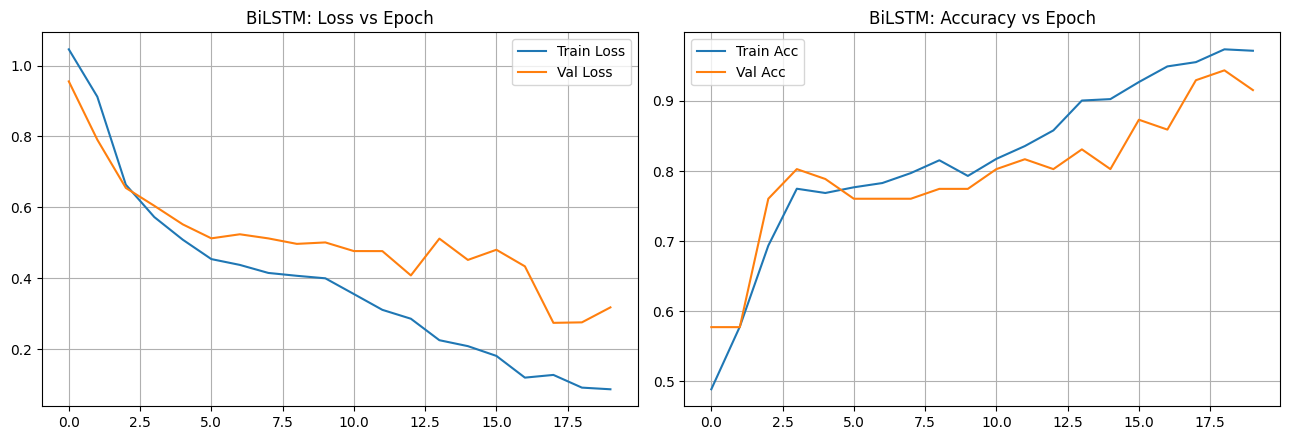


BiLSTM TEST -- Acc: 0.9149 Prec: 0.9216 Rec: 0.8000 F1: 0.8127


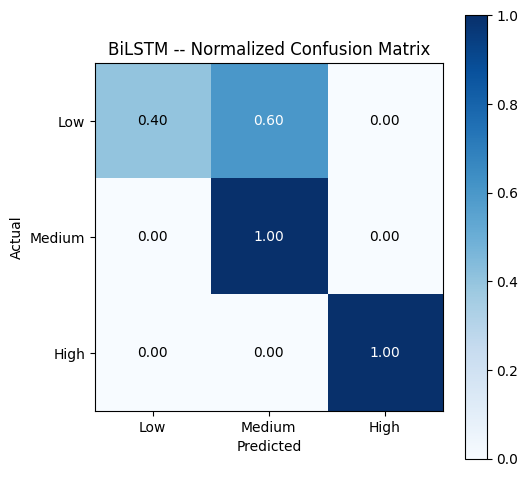

In [54]:
import torch, torch.nn as nn, torch.optim as optim, time
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def tokenize(text):
    return text.lower().replace('.', '').replace(',', '').split()

counter = Counter()
for t in train_df['text']:
    counter.update(tokenize(t))
vocab = {'<pad>': 0, '<unk>': 1}
for word, _ in counter.most_common():
    vocab[word] = len(vocab)
VOCAB_SIZE = len(vocab)
MAX_LEN = max(len(tokenize(t)) for t in df_nlp['text'])

def encode(text):
    ids = [vocab.get(tok, vocab['<unk>']) for tok in tokenize(text)]
    return ids[:MAX_LEN] + [vocab['<pad>']] * (MAX_LEN - len(ids))

class TextDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = [encode(t) for t in dataframe['text']]
        self.labels = dataframe['label_id'].tolist()
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return torch.tensor(self.texts[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

nlp_train_loader = DataLoader(TextDataset(train_df), batch_size=32, shuffle=True)
nlp_val_loader = DataLoader(TextDataset(val_df), batch_size=32, shuffle=False)
nlp_test_loader = DataLoader(TextDataset(test_df), batch_size=32, shuffle=False)

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64, n_classes=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(nn.Linear(hidden_dim*2, 32), nn.ReLU(), nn.Dropout(0.3), nn.Linear(32, n_classes))
    def forward(self, x):
        emb = self.embedding(x)
        _, (h_n, _) = self.lstm(emb)
        h_cat = torch.cat((h_n[-2], h_n[-1]), dim=1)
        return self.fc(h_cat)

nlp_model = BiLSTMClassifier(VOCAB_SIZE).to(device)
n_params = sum(p.numel() for p in nlp_model.parameters())
model_size_mb = sum(p.numel()*p.element_size() for p in nlp_model.parameters()) / (1024**2)
print(f"BiLSTM parameters: {n_params:,} | model size: {model_size_mb:.2f} MB")

optimizer = optim.AdamW(nlp_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def run_epoch(loader, train=True):
    nlp_model.train() if train else nlp_model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = nlp_model(X_batch)
            loss = criterion(logits, y_batch)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
            correct += (logits.argmax(1) == y_batch).sum().item()
            total += X_batch.size(0)
    return total_loss/total, correct/total

N_EPOCHS = 20
nlp_train_losses, nlp_val_losses, nlp_train_accs, nlp_val_accs, epoch_times = [], [], [], [], []
for epoch in range(N_EPOCHS):
    start = time.time()
    tr_loss, tr_acc = run_epoch(nlp_train_loader, True)
    v_loss, v_acc = run_epoch(nlp_val_loader, False)
    epoch_times.append(time.time() - start)
    nlp_train_losses.append(tr_loss); nlp_val_losses.append(v_loss)
    nlp_train_accs.append(tr_acc); nlp_val_accs.append(v_acc)
    print(f"Epoch {epoch+1:2d}/{N_EPOCHS} | train_loss={tr_loss:.4f} acc={tr_acc:.4f} | val_loss={v_loss:.4f} acc={v_acc:.4f} | {epoch_times[-1]:.1f}s")

avg_epoch_time = np.mean(epoch_times)
total_train_time = np.sum(epoch_times)
print(f"\nAvg time/epoch: {avg_epoch_time:.2f}s | Total: {total_train_time:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(nlp_train_losses, label='Train Loss'); axes[0].plot(nlp_val_losses, label='Val Loss')
axes[0].set_title('BiLSTM: Loss vs Epoch'); axes[0].legend(); axes[0].grid()
axes[1].plot(nlp_train_accs, label='Train Acc'); axes[1].plot(nlp_val_accs, label='Val Acc')
axes[1].set_title('BiLSTM: Accuracy vs Epoch'); axes[1].legend(); axes[1].grid()
plt.tight_layout(); plt.show()

nlp_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in nlp_test_loader:
        logits = nlp_model(X_batch.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(y_batch.numpy())

bilstm_acc = accuracy_score(all_true, all_preds)
bilstm_prec = precision_score(all_true, all_preds, average='macro', zero_division=0)
bilstm_rec = recall_score(all_true, all_preds, average='macro', zero_division=0)
bilstm_f1 = f1_score(all_true, all_preds, average='macro', zero_division=0)
print(f"\nBiLSTM TEST -- Acc: {bilstm_acc:.4f} Prec: {bilstm_prec:.4f} Rec: {bilstm_rec:.4f} F1: {bilstm_f1:.4f}")

cm = confusion_matrix(all_true, all_preds, normalize='true')
plt.figure(figsize=(5.5,5)); plt.imshow(cm, cmap='Blues', vmin=0, vmax=1)
plt.title('BiLSTM -- Normalized Confusion Matrix'); plt.colorbar()
plt.xticks([0,1,2], ['Low','Medium','High']); plt.yticks([0,1,2], ['Low','Medium','High'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{cm[i,j]:.2f}", ha='center', va='center', color='white' if cm[i,j]>0.5 else 'black')
plt.tight_layout(); plt.show()

bilstm_results = {'Model':'BiLSTM (Easy NLP)', 'Accuracy':bilstm_acc, 'Precision':bilstm_prec,
                   'Recall':bilstm_rec, 'F1':bilstm_f1, 'Params':n_params, 'Size_MB':model_size_mb,
                   'Avg_Epoch_Time_s':avg_epoch_time, 'Total_Train_Time_s':total_train_time}

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/493 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT parameters: 66,955,779 | model size: 255.42 MB


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.819283,0.601701,0.760563,0.508666
2,0.454426,0.454233,0.802817,0.648461
3,0.279794,0.386085,0.873239,0.829395
4,0.202473,0.355988,0.915493,0.908964
5,0.173382,0.344286,0.915493,0.908964



Total training time: 26.8s | Avg/epoch: 5.4s


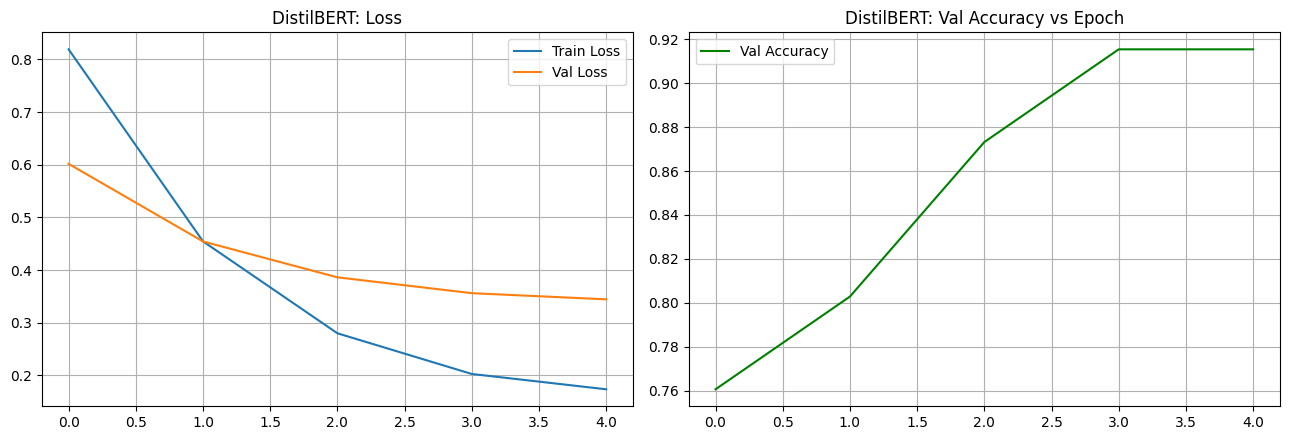


DistilBERT TEST -- Acc: 0.9504 Prec: 0.9241 Rec: 0.9410 F1: 0.9318


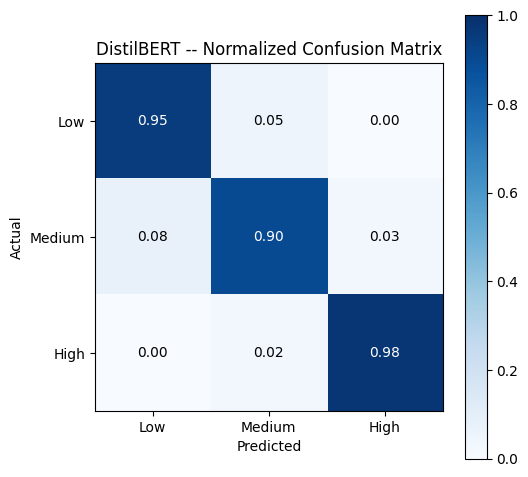

In [55]:
!pip install transformers datasets --quiet --break-system-packages

import time
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf_dataset(dataframe):
    ds = Dataset.from_pandas(dataframe[['text','label_id']].rename(columns={'label_id':'label'}))
    return ds.map(lambda x: tokenizer(x['text'], truncation=True, padding='max_length', max_length=128), batched=True)

hf_train, hf_val, hf_test = to_hf_dataset(train_df), to_hf_dataset(val_df), to_hf_dataset(test_df)

distilbert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)
n_params_bert = sum(p.numel() for p in distilbert_model.parameters())
size_mb_bert = sum(p.numel()*p.element_size() for p in distilbert_model.parameters()) / (1024**2)
print(f"DistilBERT parameters: {n_params_bert:,} | model size: {size_mb_bert:.2f} MB")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {'accuracy': accuracy_score(labels, preds), 'f1': f1_score(labels, preds, average='macro', zero_division=0)}

training_args = TrainingArguments(
    output_dir='./distilbert_sma', num_train_epochs=5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    eval_strategy='epoch', save_strategy='no', logging_strategy='epoch',
    learning_rate=2e-5, report_to='none',
)
trainer = Trainer(model=distilbert_model, args=training_args, train_dataset=hf_train,
                   eval_dataset=hf_val, compute_metrics=compute_metrics)

start = time.time()
trainer.train()
total_train_time_bert = time.time() - start
avg_epoch_time_bert = total_train_time_bert / training_args.num_train_epochs
print(f"\nTotal training time: {total_train_time_bert:.1f}s | Avg/epoch: {avg_epoch_time_bert:.1f}s")

history = trainer.state.log_history
train_loss_log = [h['loss'] for h in history if 'loss' in h]
val_loss_log = [h['eval_loss'] for h in history if 'eval_loss' in h]
val_acc_log = [h['eval_accuracy'] for h in history if 'eval_accuracy' in h]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(train_loss_log, label='Train Loss'); axes[0].plot(val_loss_log, label='Val Loss')
axes[0].set_title('DistilBERT: Loss'); axes[0].legend(); axes[0].grid()
axes[1].plot(val_acc_log, label='Val Accuracy', color='green')
axes[1].set_title('DistilBERT: Val Accuracy vs Epoch'); axes[1].legend(); axes[1].grid()
plt.tight_layout(); plt.show()

test_out = trainer.predict(hf_test)
bert_preds = np.argmax(test_out.predictions, axis=1)
bert_true = test_out.label_ids

bert_acc = accuracy_score(bert_true, bert_preds)
bert_prec = precision_score(bert_true, bert_preds, average='macro', zero_division=0)
bert_rec = recall_score(bert_true, bert_preds, average='macro', zero_division=0)
bert_f1 = f1_score(bert_true, bert_preds, average='macro', zero_division=0)
print(f"\nDistilBERT TEST -- Acc: {bert_acc:.4f} Prec: {bert_prec:.4f} Rec: {bert_rec:.4f} F1: {bert_f1:.4f}")

cm_bert = confusion_matrix(bert_true, bert_preds, normalize='true')
plt.figure(figsize=(5.5,5)); plt.imshow(cm_bert, cmap='Blues', vmin=0, vmax=1)
plt.title('DistilBERT -- Normalized Confusion Matrix'); plt.colorbar()
plt.xticks([0,1,2], ['Low','Medium','High']); plt.yticks([0,1,2], ['Low','Medium','High'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{cm_bert[i,j]:.2f}", ha='center', va='center', color='white' if cm_bert[i,j]>0.5 else 'black')
plt.tight_layout(); plt.show()

distilbert_results = {'Model':'DistilBERT (Easy LLM)', 'Accuracy':bert_acc, 'Precision':bert_prec,
                       'Recall':bert_rec, 'F1':bert_f1, 'Params':n_params_bert, 'Size_MB':size_mb_bert,
                       'Avg_Epoch_Time_s':avg_epoch_time_bert, 'Total_Train_Time_s':total_train_time_bert}

In [56]:
nlp_llm_comparison = pd.DataFrame([bilstm_results, distilbert_results]).set_index('Model')
nlp_llm_comparison[['Accuracy','Precision','Recall','F1']] = nlp_llm_comparison[['Accuracy','Precision','Recall','F1']].round(4)
nlp_llm_comparison['Size_MB'] = nlp_llm_comparison['Size_MB'].round(2)
nlp_llm_comparison['Avg_Epoch_Time_s'] = nlp_llm_comparison['Avg_Epoch_Time_s'].round(2)
print(nlp_llm_comparison.to_string())
nlp_llm_comparison.to_csv('nlp_llm_comparison.csv')

                       Accuracy  Precision  Recall      F1    Params  Size_MB  Avg_Epoch_Time_s  Total_Train_Time_s
Model                                                                                                              
BiLSTM (Easy NLP)        0.9149     0.9216   0.800  0.8127     86403     0.33              0.07            1.407017
DistilBERT (Easy LLM)    0.9504     0.9241   0.941  0.9318  66955779   255.42              5.35           26.754467


In [57]:
import pandas as pd
from google.colab import files

print("Upload electra_results.csv and tfidf_results.csv:")
uploaded = files.upload()

electra_df = pd.read_csv('electra_results.csv')
tfidf_df = pd.read_csv('tfidf_results.csv')
own_results = pd.DataFrame([bilstm_results, distilbert_results])

master_nlp_llm_table = pd.concat(
    [own_results, electra_df, tfidf_df], ignore_index=True
).set_index('Model')

master_nlp_llm_table[['Accuracy','Precision','Recall','F1']] = \
    master_nlp_llm_table[['Accuracy','Precision','Recall','F1']].round(4)
master_nlp_llm_table['Size_MB'] = master_nlp_llm_table['Size_MB'].round(2)
master_nlp_llm_table['Avg_Epoch_Time_s'] = master_nlp_llm_table['Avg_Epoch_Time_s'].round(2)

master_nlp_llm_table = master_nlp_llm_table.sort_values('F1', ascending=False)

print("=" * 90)
print("ALL 4 NLP/LLM MODELS -- COMBINED COMPARISON")
print("=" * 90)
print(master_nlp_llm_table.to_string())

master_nlp_llm_table.to_csv('master_nlp_llm_comparison.csv')
print("\n✓ Saved to master_nlp_llm_comparison.csv")

Upload electra_results.csv and tfidf_results.csv:


Saving electra_results.csv to electra_results.csv
Saving tfidf_results.csv to tfidf_results.csv
ALL 4 NLP/LLM MODELS -- COMBINED COMPARISON
                                    Accuracy  Precision  Recall      F1    Params  Size_MB  Avg_Epoch_Time_s  Total_Train_Time_s
Model                                                                                                                           
TF-IDF + Logistic Regression (NLP)    0.9716     0.9750  0.9496  0.9613      1263     0.03              0.01            0.157552
DistilBERT (Easy LLM)                 0.9504     0.9241  0.9410  0.9318  66955779   255.42              5.35           26.754467
BiLSTM (Easy NLP)                     0.9149     0.9216  0.8000  0.8127     86403     0.33              0.07            1.407017
ELECTRA-small (LLM)                   0.8014     0.5063  0.5983  0.5475  13549571    52.39              2.48            7.427757

✓ Saved to master_nlp_llm_comparison.csv


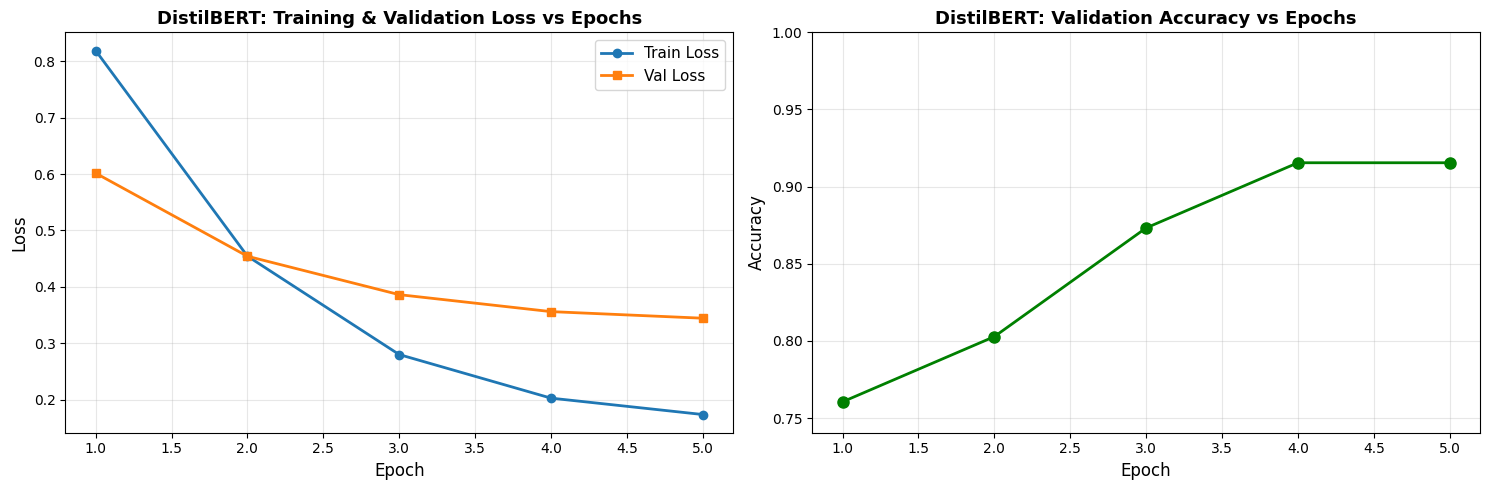

DISTILBERT — NORMALIZED CONFUSION MATRIX (Test Set)


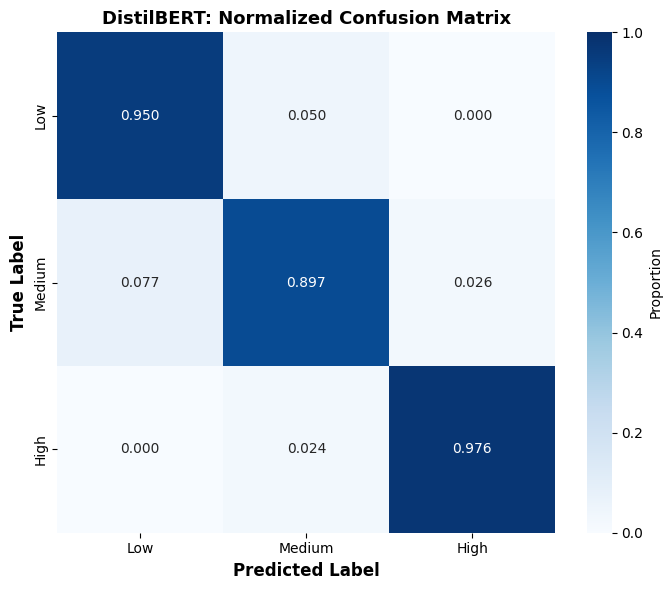


✓ Saved: distilbert_loss_accuracy_curves.png
✓ Saved: distilbert_normalized_confusion_matrix.png


In [58]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Extract from training history
history = trainer.state.log_history
epochs = [h.get('epoch', i) for i, h in enumerate(history) if 'loss' in h or 'eval_loss' in h]
train_losses = [h['loss'] for h in history if 'loss' in h]
val_losses = [h['eval_loss'] for h in history if 'eval_loss' in h]
val_accs = [h['eval_accuracy'] for h in history if 'eval_accuracy' in h]

# Recompute predictions for confusion matrix
test_out = trainer.predict(hf_test)
bert_preds = np.argmax(test_out.predictions, axis=1)
bert_true = test_out.label_ids

# Normalized confusion matrix
cm_normalized = confusion_matrix(bert_true, bert_preds, normalize='true')

# Create 2x2 subplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Loss curves
axes[0].plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Train Loss', linewidth=2)
axes[0].plot(range(1, len(val_losses)+1), val_losses, marker='s', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('DistilBERT: Training & Validation Loss vs Epochs', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy curve
axes[1].plot(range(1, len(val_accs)+1), val_accs, marker='o', color='green', linewidth=2, markersize=8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('DistilBERT: Validation Accuracy vs Epochs', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([min(val_accs)-0.02, 1.0])

plt.tight_layout()
plt.savefig('distilbert_loss_accuracy_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("=" * 80)
print("DISTILBERT — NORMALIZED CONFUSION MATRIX (Test Set)")
print("=" * 80)

# Plot normalized confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'],
            cbar_kws={'label': 'Proportion'}, ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('DistilBERT: Normalized Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distilbert_normalized_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: distilbert_loss_accuracy_curves.png")
print("✓ Saved: distilbert_normalized_confusion_matrix.png")

In [65]:
import numpy as np
import pandas as pd

print("=" * 80)
print("DISTILBERT — XAI: WORD ABLATION IMPORTANCE")
print("=" * 80)

device_xai = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
distilbert_model.to(device_xai)
distilbert_model.eval()

def predict_text(text):
    """Return predicted class and confidence"""
    encoding = tokenizer(text, truncation=True, padding='max_length',
                         max_length=128, return_tensors='pt')
    encoding = {k: v.to(device_xai) for k, v in encoding.items()}
    with torch.no_grad():
        outputs = distilbert_model(**encoding)
        probs = torch.softmax(outputs.logits, dim=1)[0]
        pred_class = torch.argmax(probs).item()
        confidence = probs[pred_class].item()
    return pred_class, confidence

def word_importance(text):
    """Remove each word, measure how much prediction confidence drops"""
    words = text.split()
    original_pred, original_conf = predict_text(text)

    importance_scores = []
    for i, word in enumerate(words):
        # Remove word i
        ablated_text = ' '.join([w for j, w in enumerate(words) if j != i])
        ablated_pred, ablated_conf = predict_text(ablated_text)

        # Importance = how much confidence dropped
        importance = original_conf - ablated_conf
        importance_scores.append((word, importance))

    return original_pred, original_conf, importance_scores

id2label = {0: 'Low', 1: 'Medium', 2: 'High'}

# Analyze 3 test examples
for idx in range(min(3, len(test_df))):
    text = test_df['text'].iloc[idx]
    true_label = test_df['label_id'].iloc[idx]

    pred_label, confidence, importance = word_importance(text)

    # Sort by importance
    importance.sort(key=lambda x: x[1], reverse=True)
    top_words = importance[:10]

    match = "✓" if pred_label == true_label else "✗"
    print(f"\nExample {idx+1} {match}")
    print(f"  True: {id2label[true_label]:8s} | Predicted: {id2label[pred_label]:8s} (confidence: {confidence:.3f})")
    print(f"  Text: {text[:120]}...")
    print("  Top 10 Most Important Words (removal impact on confidence):")
    for word, imp in top_words:
        bar = '█' * int(imp * 100)
        print(f"    {word:25s} | {bar} {imp:.4f}")

print("\n✓ Word ablation XAI complete")
print("  (Higher value = word is more critical to the model's prediction)")

DISTILBERT — XAI: WORD ABLATION IMPORTANCE

Example 1 ✓
  True: High     | Predicted: High     (confidence: 0.977)
  Text: A 19-year-old female student, academic level Undergraduate, from Spain, spends 5.0 hours per day on social media, mainly...
  Top 10 Most Important Words (removal impact on confidence):
    negatively                | █████████████████████████ 0.2521
    affected                  | ██ 0.0270
    3                         |  0.0025
    is                        |  0.0021
    Single.                   |  0.0016
    conflicts                 |  0.0016
    and                       |  0.0006
    student,                  |  0.0006
    Undergraduate,            |  0.0006
    media,                    |  0.0006

Example 2 ✓
  True: Medium   | Predicted: Medium   (confidence: 0.803)
  Text: A 19-year-old female student, academic level Undergraduate, from Ireland, spends 4.0 hours per day on social media, main...
  Top 10 Most Important Words (removal impact on confidence)

In [67]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

print("=" * 80)
print("DISTILBERT — ABLATION STUDY: IMPACT OF REMOVING KEY WORDS")
print("=" * 80)

device_abl = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def predict_text(text):
    """Return predicted class and confidence"""
    encoding = tokenizer(text, truncation=True, padding='max_length',
                         max_length=128, return_tensors='pt')
    encoding = {k: v.to(device_abl) for k, v in encoding.items()}
    with torch.no_grad():
        outputs = distilbert_model(**encoding)
        pred_class = torch.argmax(outputs.logits, dim=1).item()
    return pred_class

def word_importance(text):
    """Remove each word, measure confidence drop"""
    words = text.split()
    original_pred, original_conf = predict_text(text), None

    importance_scores = []
    for i, word in enumerate(words):
        ablated_text = ' '.join([w for j, w in enumerate(words) if j != i])
        ablated_pred = predict_text(ablated_text)
        importance = 1.0 if ablated_pred != original_pred else 0.0  # Binary: changes prediction or not
        importance_scores.append((word, importance))

    return importance_scores

# Find globally important words (words that change predictions when removed)
print("\nAnalyzing word importance across test set...")
all_word_importance = {}

for idx in range(min(50, len(test_df))):  # Sample 50 test examples for speed
    text = test_df['text'].iloc[idx]
    importance = word_importance(text)

    for word, imp in importance:
        if word not in all_word_importance:
            all_word_importance[word] = []
        all_word_importance[word].append(imp)

# Average importance per word
avg_importance = {word: np.mean(scores) for word, scores in all_word_importance.items()}
sorted_words = sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)
top_important_words = [w for w, _ in sorted_words[:10]]

print(f"\nTop 10 Most Important Words (% of times removal changes prediction):")
for word, imp in sorted_words[:10]:
    print(f"  {word:25s} | Impact: {imp*100:5.1f}%")

# ============================================================================
# ABLATION: Evaluate model on test set WITH top words removed
# ============================================================================

print(f"\n\nAblating top 10 words: {top_important_words}")
print("Evaluating on FULL test set...\n")

original_preds = []
ablated_preds = []

for idx in range(len(test_df)):
    text = test_df['text'].iloc[idx]

    # Original prediction
    orig_pred = predict_text(text)
    original_preds.append(orig_pred)

    # Ablated prediction (remove top words)
    words = text.split()
    ablated_text = ' '.join([w for w in words if w.lower() not in top_important_words])
    abl_pred = predict_text(ablated_text)
    ablated_preds.append(abl_pred)

# Compute metrics
original_preds = np.array(original_preds)
ablated_preds = np.array(ablated_preds)
true_labels = test_df['label_id'].values

original_acc = accuracy_score(true_labels, original_preds)
original_f1 = f1_score(true_labels, original_preds, average='macro', zero_division=0)

ablated_acc = accuracy_score(true_labels, ablated_preds)
ablated_f1 = f1_score(true_labels, ablated_preds, average='macro', zero_division=0)

acc_drop = original_acc - ablated_acc
f1_drop = original_f1 - ablated_f1

# ============================================================================
# RESULTS
# ============================================================================

print("=" * 80)
print("ABLATION STUDY RESULTS")
print("=" * 80)

results_table = pd.DataFrame({
    'Condition': ['Original Model', f'Ablated (no: {", ".join(top_important_words[:5])}...)'],
    'Accuracy': [f'{original_acc:.4f}', f'{ablated_acc:.4f}'],
    'Macro F1': [f'{original_f1:.4f}', f'{ablated_f1:.4f}'],
})

print("\n" + results_table.to_string(index=False))

print(f"\n\nPerformance Drop:")
print(f"  Accuracy: {original_acc:.4f} → {ablated_acc:.4f} (drop: {acc_drop:.4f}, {acc_drop*100:.2f}%)")
print(f"  Macro F1: {original_f1:.4f} → {ablated_f1:.4f} (drop: {f1_drop:.4f}, {f1_drop*100:.2f}%)")

if acc_drop > 0.05:
    print(f"\n→ Removing these words SIGNIFICANTLY HURTS model performance.")
    print(f"  Interpretation: These are CRITICAL words for addiction prediction.")
else:
    print(f"\n→ Removing these words has MINIMAL IMPACT on performance.")
    print(f"  Interpretation: Model relies on broader patterns, not specific keywords.")

results_table.to_csv('distilbert_ablation_study.csv', index=False)
print("\n✓ Saved: distilbert_ablation_study.csv")

DISTILBERT — ABLATION STUDY: IMPACT OF REMOVING KEY WORDS

Analyzing word importance across test set...

Top 10 Most Important Words (% of times removal changes prediction):
  Ireland,                  | Impact: 100.0%
  Japan,                    | Impact: 100.0%
  Denmark,                  | Impact: 100.0%
  Switzerland,              | Impact: 100.0%
  Sri                       | Impact: 100.0%
  Lanka,                    | Impact: 100.0%
  Netherlands,              | Impact: 100.0%
  negatively                | Impact:  53.3%
  7.2                       | Impact:  50.0%
  1                         | Impact:  50.0%


Ablating top 10 words: ['Ireland,', 'Japan,', 'Denmark,', 'Switzerland,', 'Sri', 'Lanka,', 'Netherlands,', 'negatively', '7.2', '1']
Evaluating on FULL test set...

ABLATION STUDY RESULTS

                                                     Condition Accuracy Macro F1
                                                Original Model   0.9504   0.9318
Ablated (no: Ireland,, 